In [1]:
# ==============================================================
# 0. 导入 & 全局配置
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import copy
import pickle
import warnings

from numpy.linalg import svd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

# 中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

SEED = 42
np.random.seed(SEED)

In [62]:
import importlib
import sparsification
importlib.reload(sparsification)

<module 'sparsification' from 'C:\\Users\\liu.xuanc\\Desktop\\Code\\network-dynamic-identification\\sparsification.py'>

In [63]:
# ── External function libraries ──
# netdyn.py          : dynamics model classes (LVDynamics, SISDynamics, ...)
# LASSOreconstruction.py : reconstruct_network(X, model, rho, ...)
# sparsification.py  : sparsify_network_v2(A_true, U_dyn, epsilon, ...)
#                      extract_dynamical_basis(X_obs, energy_threshold, min_k)
#                      compute_effective_matrix(A, U_dyn)

from netdyn import *  # LVDynamics / SISDynamics / KuramotoDynamics 等
from LASSOreconstruction import lasso_reconstruct_network
from sparsification import sparsify_network_v2, extract_dynamical_basis, compute_effective_matrix
from sparsification import find_kernel_edges, sparsify_by_projection, compute_order_parameter_LV

In [4]:
# help(sparsify_network_v2)

In [5]:
# ==============================================================
# 1. 网络初始化 & 动力学模拟
# ==============================================================

def initialize_adjacency_matrix(matrix, seed=None):
    """将邻接矩阵中的 1 随机初始化为 [0.5, 1.5] 的权重，0 保持不变。"""
    if seed is not None:
        np.random.seed(seed)
    matrix = np.array(matrix, dtype=float)
    mask = (matrix == 1)
    matrix[mask] = np.random.uniform(0.5, 1.5, size=mask.sum())
    return matrix

In [6]:
# ==============================================================
# 3. 误差度量（NRMSE）
# ==============================================================

def compute_nrmse(X_true, X_pred):
    """
    归一化均方根误差（NRMSE）。

    NRMSE = ‖X_pred - X_true‖_F / ‖X_true‖_F

    范围 [0, ∞)，值越小表示越接近。
    经验阈值：< 0.05 强等价，0.05~0.15 弱等价，> 0.15 不等价。

    参数
    ----
    X_true, X_pred : np.ndarray，形状相同（T, N）或可广播

    返回
    ----
    nrmse : float
    """
    n      = min(len(X_true), len(X_pred))
    diff   = X_true[:n] - X_pred[:n]
    denom  = np.linalg.norm(X_true[:n], 'fro')
    if denom < 1e-12:
        return 0.0
    return float(np.linalg.norm(diff, 'fro') / denom)

In [7]:
def evaluate_prediction_nrmse(X_true, X_pred, t_split):
    """
    计算 t > t_split 区间的预测 NRMSE 及逐时刻 NRMSE。

    返回
    ----
    nrmse_t   : np.ndarray  逐时刻 NRMSE（各节点平均）
    nrmse_bar : float       全局 NRMSE
    """
    X_ref  = X_true[t_split:]
    X_pred = X_pred[t_split:]
    if len(X_ref) == 0:
        return None, None
    n          = min(len(X_ref), len(X_pred))
    diff       = X_ref[:n] - X_pred[:n]
    denom_t    = np.linalg.norm(X_ref[:n], axis=1, keepdims=True)
    denom_t    = np.where(denom_t < 1e-12, 1.0, denom_t)
    nrmse_t    = np.linalg.norm(diff, axis=1) / denom_t.squeeze()
    nrmse_bar  = compute_nrmse(X_ref[:n], X_pred[:n])
    return nrmse_t, nrmse_bar

In [8]:
# ==============================================================
# 5. 等价族构造
# ==============================================================

def construct_equivalent_network(A_eff_ref, U_dyn, sparsity_target,
                                  rho_ref=None, seed=None):
    """
    从给定的 A_eff_ref 出发，构造一个目标稀疏度的功能等价网络。

    原理：A' = A_eff_ref + N_null
    其中 N_null = Q @ R @ Q，Q = I - P 是 U_dyn 的零空间投影算符。
    N_null 满足 P @ N_null @ P ≈ 0，因此不改变 A_eff。

    参数
    ----
    A_eff_ref      : np.ndarray (N, N)  目标 A_eff（功能基准）
    U_dyn          : np.ndarray (N, k)  动力学子空间基底
    sparsity_target: float              目标保留边比例（如 0.05 = 5%）
    rho_ref        : float or None      谱半径归一化目标；None 则用 A_eff_ref 的谱半径
    seed           : int or None

    返回
    ----
    A_equiv : np.ndarray (N, N)  等价网络（非负权重，谱半径已归一化）
    delta   : float              实际 A_eff 偏差（验证用）
    """
    if seed is not None:
        np.random.seed(seed)
    N  = A_eff_ref.shape[0]
    P  = U_dyn @ U_dyn.T
    Q  = np.eye(N) - P

    # 零空间随机扰动
    R      = np.random.randn(N, N)
    N_null = Q @ R @ Q

    # 合成候选网络（取绝对值保证非负，与大多数生态/流行病模型一致）
    A_cand = np.abs(A_eff_ref + N_null)
    np.fill_diagonal(A_cand, 0.0)

    # 按目标稀疏度截断
    n_total  = N * N - N          # 不含对角线
    n_keep   = max(1, int(sparsity_target * n_total))
    flat     = A_cand.copy()
    np.fill_diagonal(flat, 0.0)
    threshold = np.sort(flat.flatten())[-n_keep]
    A_out     = np.where(flat >= threshold, flat, 0.0)
    np.fill_diagonal(A_out, 0.0)

    # 谱半径归一化
    if rho_ref is None:
        rho_ref = float(np.max(np.abs(np.linalg.eigvals(A_eff_ref))))
    rho_out = float(np.max(np.abs(np.linalg.eigvals(A_out))))
    if rho_out > 1e-9:
        A_out *= rho_ref / rho_out

    # 计算实际 A_eff 偏差（验证）
    delta = _aeff_deviation(A_out, A_eff_ref, U_dyn)

    return A_out, delta

In [9]:
def build_equivalence_family(A_eff_ref, U_dyn, sparsity_levels,
                              n_samples_per_level=5, rho_ref=None, seed=0):
    """
    构造不同稀疏度下的等价族——每个稀疏度生成多个形态各异的等价网络。

    参数
    ----
    A_eff_ref          : np.ndarray (N, N)
    U_dyn              : np.ndarray (N, k)
    sparsity_levels    : list of float  目标稀疏度列表
    n_samples_per_level: int            每个稀疏度生成的网络数量
    rho_ref            : float or None
    seed               : int            随机基础种子

    返回
    ----
    family : list of dict，每项含：
             sparsity / seed / A_equiv / delta
    """
    family = []
    for sp in sparsity_levels:
        for s in range(n_samples_per_level):
            A_eq, delta = construct_equivalent_network(
                A_eff_ref, U_dyn,
                sparsity_target=sp,
                rho_ref=rho_ref,
                seed=seed + s * 100 + int(sp * 1000)
            )
            family.append({
                "sparsity": sp,
                "seed":     seed + s * 100 + int(sp * 1000),
                "A_equiv":  A_eq,
                "delta":    delta,
            })
    print(f"等价族构造完成：{len(sparsity_levels)} 个稀疏度 × "
          f"{n_samples_per_level} 个样本 = {len(family)} 个网络")
    return family

In [10]:
# ==============================================================
# 6. 简并性验证实验
# ==============================================================

def verify_equivalence_family(family, model, X_obs, T_train_steps,
                               T_sim=500, seed=42):
    """
    对等价族中的每个网络运行动力学模拟，计算 NRMSE 验证功能等价性。

    参数
    ----
    family        : list of dict，由 build_equivalence_family 返回
    model         : NetworkDynamics
    X_obs         : np.ndarray (T, N)  完整 Ground Truth 轨迹
    T_train_steps : int
    T_sim         : int  模拟步数
    seed          : int

    返回
    ----
    results : list of dict，每项在 family 原有字段基础上增加：
              nrmse / X_pred
    """
    np.random.seed(seed)
    init_state = X_obs[T_train_steps]
    steps_pred = len(X_obs) - T_train_steps
    X_train    = X_obs[:T_train_steps]

    results = []
    print(f"\n{'稀疏度':>8} {'seed':>8} {'δ(A_eff)':>10} {'NRMSE':>8} {'等价性':>8}")
    print("─" * 50)

    for item in family:
        try:
            X_pred = model.simulate(
                item["A_equiv"], T_steps=steps_pred, init_state=init_state
            )
            X_full = np.vstack([X_train, X_pred])
            _, nrmse = evaluate_prediction_nrmse(X_obs, X_full, T_train_steps)
        except Exception as e:
            print(f"  模拟失败（seed={item['seed']}）：{e}")
            nrmse  = np.inf
            X_full = None

        label = ("强等价" if nrmse < 0.05 else
                 "弱等价" if nrmse < 0.15 else "不等价")

        results.append({**item, "nrmse": nrmse, "X_pred": X_full})
        print(f"{item['sparsity']:>8.3f} {item['seed']:>8} "
              f"{item['delta']:>10.4f} {nrmse:>8.4f} {label:>8}")

    return results

In [11]:
# ==============================================================
# 7. 可视化
# ==============================================================

def _save_or_show(fig, save_path):
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"图片已保存：{save_path}")
        plt.close(fig)
    else:
        plt.show()


def plot_trajectory_comparison(A_true, A_proxy, X_obs, X_proxy,
                                T_train_steps, num_nodes=10,
                                scatter_interval=3,
                                name_proxy="A_proxy",
                                save_path=None):
    """
    对比两个网络的拓扑热图及动力学轨迹（实线 vs 散点）。
    """
    N       = A_true.shape[0]
    T_total = X_obs.shape[0]
    t_ax    = np.arange(T_total)
    n_plot  = min(num_nodes, N)
    nodes   = np.linspace(0, N - 1, n_plot, dtype=int)
    colors  = [plt.cm.tab10(i % 10) for i in range(n_plot)]

    fig  = plt.figure(figsize=(14, 10))
    grid = plt.GridSpec(2, 2, height_ratios=[1, 1.5])

    for col, (A, cmap, name) in enumerate([
        (A_true,  'Blues', r'$A_{\rm true}$'),
        (A_proxy, 'Reds',  name_proxy)
    ]):
        ax  = fig.add_subplot(grid[0, col])
        cax = ax.imshow(A, cmap=cmap, interpolation='nearest')
        ax.set_title(name); fig.colorbar(cax, ax=ax)

    corr = np.corrcoef(A_true.flatten(), A_proxy.flatten())[0, 1]
    fig.axes[1].set_xlabel(f"拓扑相关系数：{corr:.4f}")

    ax3 = fig.add_subplot(grid[1, :])
    sp  = np.arange(0, T_total, scatter_interval)
    sp  = sp[sp < len(X_proxy)]
    for idx, node in enumerate(nodes):
        c = colors[idx]
        ax3.plot(t_ax, X_obs[:, node], color=c, lw=2, alpha=0.6)
        ax3.scatter(t_ax[sp], X_proxy[sp, node],
                    edgecolors=c, facecolors='none',
                    marker='o', s=40, lw=1.5)
    ax3.axvline(T_train_steps, color='k', ls=':', lw=2)
    ax3.legend([
        Line2D([0], [0], color='gray', lw=2),
        Line2D([0], [0], color='gray', marker='o', ls='None',
               markerfacecolor='none', markeredgewidth=1.5)
    ], ['Ground Truth', name_proxy], loc='upper left', fontsize=10)
    ax3.set_title(f"动力学对比（展示 {n_plot} 个节点）")
    ax3.set_xlabel("时间步"); ax3.set_ylabel(r"$x_i(t)$")
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig, save_path)


def plot_nrmse_comparison(X_obs, pred_dict, t_split, dt=0.1,
                           title=None, save_path=None):
    """
    对比多个网络在预测区间的逐时刻 NRMSE 曲线。

    参数
    ----
    pred_dict : dict {label: X_pred}
    """
    X_ref     = X_obs[t_split:]
    T_future  = len(X_ref)
    t_horizon = np.arange(T_future) * dt
    colors    = [plt.cm.tab10(i % 10) for i in range(len(pred_dict))]

    fig, ax = plt.subplots(figsize=(10, 6))
    print(f"{'标签':<35} {'全局 NRMSE':>12}")
    print("─" * 50)

    for (label, X_pred), color in zip(pred_dict.items(), colors):
        Xp   = X_pred[t_split:]
        n    = min(len(Xp), T_future)
        diff = X_ref[:n] - Xp[:n]
        denom_t = np.linalg.norm(X_ref[:n], axis=1)
        denom_t = np.where(denom_t < 1e-12, 1.0, denom_t)
        nrmse_t = np.linalg.norm(diff, axis=1) / denom_t
        nrmse_bar = compute_nrmse(X_ref[:n], Xp[:n])

        print(f"{label:<35} {nrmse_bar:>12.6f}")
        ax.plot(t_horizon[:n], nrmse_t, lw=1.8, color=color, label=label)

    ax.set_xlabel(r"预测时间 $\tilde{t}$", fontsize=12)
    ax.set_ylabel("NRMSE", fontsize=12)
    ax.set_title(title or "预测误差对比（NRMSE）", fontsize=13)
    ax.axhline(0.05, color='gray', ls='--', lw=1, alpha=0.6, label='强等价阈值 0.05')
    ax.axhline(0.15, color='gray', ls=':',  lw=1, alpha=0.6, label='弱等价阈值 0.15')
    ax.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    _save_or_show(fig, save_path)


def plot_equivalence_family(results, nrmse_threshold=0.15, save_path=None):
    sparsities = sorted(set(r['sparsity'] for r in results))
    colors     = plt.cm.viridis(np.linspace(0, 0.9, len(sparsities)))
    sp_color   = {sp: c for sp, c in zip(sparsities, colors)}

    groups = {sp: [] for sp in sparsities}
    for r in results:
        if np.isfinite(r['nrmse']):
            groups[r['sparsity']].append(r['nrmse'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax   = axes[0]
    data = [groups[sp] for sp in sparsities]
    lbls = [f"{sp:.2f}" for sp in sparsities]
    bp   = ax.boxplot(data, labels=lbls, patch_artist=True)
    for patch, sp in zip(bp['boxes'], sparsities):
        patch.set_facecolor(sp_color[sp]); patch.set_alpha(0.7)
    ax.axhline(0.05, color='steelblue', ls='--', lw=1.2, label='Strong equiv. 0.05')
    ax.axhline(nrmse_threshold, color='tomato', ls='--', lw=1.2,
               label=f'Equiv. boundary {nrmse_threshold}')
    ax.set_xlabel("Target sparsity"); ax.set_ylabel("NRMSE")
    ax.set_title("Equivalence Family: NRMSE by Sparsity")
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    for r in results:
        if not np.isfinite(r['nrmse']):
            continue
        ax.scatter(r['delta'], r['nrmse'],
                   color=sp_color[r['sparsity']], s=60, alpha=0.8,
                   edgecolors='k', lw=0.5)
    ax.axhline(nrmse_threshold, color='tomato', ls='--', lw=1.2,
               label=f'Equiv. boundary {nrmse_threshold}')
    ax.set_xlabel(r"$A_\mathrm{eff}$ deviation $\delta$")
    ax.set_ylabel("NRMSE")
    ax.set_title(r"$A_\mathrm{eff}$ Deviation vs Dynamical Error")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    sm = ScalarMappable(cmap='viridis',
                        norm=Normalize(vmin=min(sparsities), vmax=max(sparsities)))
    sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='Sparsity')

    plt.suptitle("Structural Degeneracy: Equivalence Family Verification", fontsize=14)
    plt.tight_layout()
    _save_or_show(fig, save_path)

In [36]:
# ==============================================================
# 8. Epsilon percolation experiment
# ==============================================================
def compute_order_parameter_LV(A, model, T_steady=150, init_state=None, seed=42):
    """
    Compute the order parameter for Lotka-Volterra (or generic mutualistic)
    dynamics: steady-state mean abundance averaged over all nodes.

    Phi(A) = (1/N) * mean_{t in steady window} sum_i x_i(t)

    The last 20% of the T_steady steps are used as the steady-state window.

    Parameters
    ----------
    A          : (N, N)
    model      : NetworkDynamics  (must expose .simulate and .N)
    T_steady   : int   total simulation steps (should be long enough to reach
                       steady state; default 150)
    init_state : (N,) or None   initial condition; None -> uniform random
    seed       : int

    Returns
    -------
    phi      : float   scalar order parameter
    x_inf    : (N,)    node-level steady-state mean (for diagnostics)
    """
    if init_state is None:
        np.random.seed(seed)
        init_state = np.random.rand(model.N)

    X = model.simulate(A, T_steps=T_steady, init_state=init_state)

    # Use last 20% as steady-state window
    t_ss  = max(1, int(0.8 * T_steady))
    x_inf = np.mean(X[t_ss:], axis=0)   # (N,)
    phi   = float(np.mean(x_inf))
    return phi, x_inf

In [35]:
def scan_epsilon_percolation(A_true, U_dyn, model, X_obs, T_train_steps,
                              epsilon_range, T_sim=500, T_steady=150,
                              seed=42, verbose=True):
    """
    Sweep epsilon values and record structural and functional metrics
    for each resulting sparse network.

    Metrics recorded per epsilon:
      sparsity  : n_edges(A_sparse) / n_edges(A_true)
      delta     : relative A_eff Frobenius deviation
      nrmse     : NRMSE of predicted trajectory vs ground truth
      eps_macro : order parameter distance
                  |Phi(A_sparse) - Phi(A_true)| / |Phi(A_true)|
                  Phi = steady-state mean node abundance (LV)
      alignment : leading left singular vector cosine^2 alignment
      eff_rank  : participation ratio of A_eff singular values
      rho_ratio : spectral_radius(A_sparse) / spectral_radius(A_true)

    Parameters
    ----------
    A_true        : (N, N)
    U_dyn         : (N, k)
    model         : NetworkDynamics
    X_obs         : (T, N) ground-truth trajectory
    T_train_steps : int
    epsilon_range : array-like
    T_sim         : int  simulation steps for NRMSE (default 500)
    T_steady      : int  simulation steps for order parameter (default 150)
    seed          : int
    verbose       : bool

    Returns
    -------
    records : list of dict
              epsilon / sparsity / delta / nrmse / eps_macro /
              alignment / eff_rank / rho_ratio / A_sparse
    """
    np.random.seed(seed)
    init_state   = X_obs[0]          # unified initial condition from data
    steps_pred   = len(X_obs) - T_train_steps
    X_train      = X_obs[:T_train_steps]
    A_eff_ref    = compute_effective_matrix(A_true, U_dyn)
    n_edges_true = int(np.sum(np.abs(A_true) > 1e-9))
    rho_true     = float(np.max(np.abs(np.linalg.eigvals(A_true))))

    # Reference quantities for A_true
    U_true, _, _ = np.linalg.svd(A_true, full_matrices=False)
    v1_true      = U_true[:, 0]

    phi_true, _ = compute_order_parameter_LV(
        A_true, model, T_steady=T_steady, init_state=init_state, seed=seed
    )
    if verbose:
        print(f"A_true order parameter Phi = {phi_true:.4f}")

    records = []

    if verbose:
        print(f"\nEpsilon percolation scan: {len(epsilon_range)} points")
        print(f"{'eps':>8} {'sparsity':>9} {'delta':>8} {'NRMSE':>8} "
              f"{'eps_mac':>9} {'align':>8} {'PR':>8} {'rho_r':>7}")
        print("-" * 72)

    for eps in epsilon_range:
        A_sparse, _ = sparsify_network_v2(
            A_true, U_dyn, epsilon=eps, verbose=False
        )

        # ── Sparsity ──
        n_sp     = int(np.sum(np.abs(A_sparse) > 1e-9))
        sparsity = n_sp / max(n_edges_true, 1)

        # ── A_eff deviation delta ──
        A_eff_sp = compute_effective_matrix(A_sparse, U_dyn)
        ref_norm = np.linalg.norm(A_eff_ref, 'fro')
        delta    = (float(np.linalg.norm(A_eff_sp - A_eff_ref, 'fro') / ref_norm)
                    if ref_norm > 1e-12 else 0.0)

        # ── Order parameter distance (eps_macro) ──
        phi_sp, _ = compute_order_parameter_LV(
            A_sparse, model, T_steady=T_steady,
            init_state=init_state, seed=seed
        )
        eps_macro = (abs(phi_sp - phi_true) / abs(phi_true)
                     if abs(phi_true) > 1e-9 else abs(phi_sp - phi_true))

        # ── Singular vector alignment ──
        U_sp, _, _ = np.linalg.svd(A_sparse, full_matrices=False)
        alignment  = float(np.dot(v1_true, U_sp[:, 0]) ** 2)

        # ── A_eff effective rank (PR) ──
        sv_sp    = np.linalg.svd(A_eff_sp, compute_uv=False)
        sv_sp    = sv_sp[sv_sp > 1e-12]
        eff_rank = (float((sv_sp.sum() ** 2) / (sv_sp ** 2).sum())
                    if len(sv_sp) > 0 else 0.0)

        # ── Spectral radius ratio ──
        rho_sp    = float(np.max(np.abs(np.linalg.eigvals(A_sparse))))
        rho_ratio = rho_sp / rho_true if rho_true > 1e-12 else np.inf

        # ── NRMSE ──
        try:
            X_pred = model.simulate(
                A_sparse, T_steps=steps_pred,
                init_state=X_obs[T_train_steps]
            )
            X_full = np.vstack([X_train, X_pred])
            _, nrmse = evaluate_prediction_nrmse(X_obs, X_full, T_train_steps)
        except Exception:
            nrmse = np.inf

        records.append({
            "epsilon":   eps,
            "sparsity":  sparsity,
            "delta":     delta,
            "nrmse":     nrmse,
            "eps_macro": eps_macro,
            "alignment": alignment,
            "eff_rank":  eff_rank,
            "rho_ratio": rho_ratio,
            "A_sparse":  A_sparse,
        })

        if verbose:
            print(f"{eps:>8.4f} {sparsity:>9.4f} {delta:>8.4f} {nrmse:>8.4f} "
                  f"{eps_macro:>9.4f} {alignment:>8.4f} {eff_rank:>8.2f} "
                  f"{rho_ratio:>7.4f}")

    return records

In [37]:
def plot_epsilon_percolation(records, nrmse_strong=0.05, nrmse_weak=0.15,
                              save_path_main=None, save_path_scatter=None,
                              save_path_indicators=None):

    valid        = [r for r in records if np.isfinite(r['nrmse'])]
    eps_arr      = np.array([r['epsilon']   for r in valid])
    sparsity_arr = np.array([r['sparsity']  for r in valid])
    delta_arr    = np.array([r['delta']     for r in valid])
    nrmse_arr    = np.array([r['nrmse']     for r in valid])
    eps_mac_arr  = np.array([r['eps_macro'] for r in valid])
    align_arr    = np.array([r['alignment'] for r in valid])
    pr_arr       = np.array([r['eff_rank']  for r in valid])
    rho_r_arr    = np.array([r['rho_ratio'] for r in valid])

    cross_idx = np.where(nrmse_arr > nrmse_weak)[0]
    eps_crit  = eps_arr[cross_idx[0]] if len(cross_idx) > 0 else None

    # Figure 1: dual-axis epsilon vs sparsity & NRMSE
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()
    color_sp, color_nrmse = 'steelblue', 'tomato'
    l1, = ax1.plot(eps_arr, sparsity_arr, 'o-', color=color_sp, lw=2, ms=5,
                   label='Sparsity (fraction retained)')
    l2, = ax2.plot(eps_arr, nrmse_arr, 's-', color=color_nrmse, lw=2, ms=5,
                   label='NRMSE')
    ax2.axhline(nrmse_strong, color=color_nrmse, ls='--', lw=1, alpha=0.5,
                label=f'Strong equiv. {nrmse_strong}')
    ax2.axhline(nrmse_weak, color=color_nrmse, ls=':', lw=1, alpha=0.5,
                label=f'Weak equiv. {nrmse_weak}')
    if eps_crit is not None:
        ax1.axvline(eps_crit, color='gray', ls='--', lw=1.2, alpha=0.7)
        ax1.text(eps_crit, ax1.get_ylim()[0], f'  eps*={eps_crit:.3f}',
                 color='gray', fontsize=9, va='bottom')
    ax1.set_xlabel('Tolerance epsilon', fontsize=12)
    ax1.set_ylabel('Sparsity (edges / edges_true)', color=color_sp, fontsize=11)
    ax2.set_ylabel('NRMSE', color=color_nrmse, fontsize=11)
    ax1.tick_params(axis='y', labelcolor=color_sp)
    ax2.tick_params(axis='y', labelcolor=color_nrmse)
    ax1.legend([l1, l2], [l1.get_label(), l2.get_label()],
               loc='upper left', fontsize=10)
    ax1.set_title('Epsilon Percolation: Sparsity and NRMSE vs Epsilon', fontsize=13)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig1, save_path_main)

    # Figure 2: delta vs NRMSE scatter
    fig2, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(delta_arr, nrmse_arr, c=eps_arr, cmap='plasma',
                    s=70, alpha=0.85, edgecolors='k', lw=0.4)
    plt.colorbar(sc, ax=ax, label='Tolerance epsilon')
    ax.axhline(nrmse_strong, color='gray', ls='--', lw=1, alpha=0.6,
               label=f'Strong equiv. {nrmse_strong}')
    ax.axhline(nrmse_weak, color='gray', ls=':', lw=1, alpha=0.6,
               label=f'Weak equiv. {nrmse_weak}')
    ax.set_xlabel('A_eff deviation delta', fontsize=12)
    ax.set_ylabel('NRMSE', fontsize=12)
    ax.set_title('A_eff Deviation vs Dynamical Error\n(colour = tolerance epsilon)',
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig2, save_path_scatter)

    # Figure 3: 2x3 structural + functional indicators
    fig3, axes = plt.subplots(2, 3, figsize=(16, 9))

    panel_cfg = [
        (axes[0, 0], align_arr,   'Singular vector alignment\ncos^2(u1_true, u1_sparse)',
         'steelblue',  (0, 1.05), True,  False),
        (axes[0, 1], pr_arr,      'A_eff effective rank (PR)',
         'darkorange', None,      False, False),
        (axes[0, 2], nrmse_arr,   'NRMSE',
         'tomato',     None,      False, True),
        (axes[1, 0], rho_r_arr,   'Spectral radius ratio\nrho_sparse / rho_true',
         'seagreen',   None,      False, False),
        (axes[1, 1], delta_arr,   'A_eff deviation delta',
         'slategray',  None,      False, False),
        (axes[1, 2], eps_mac_arr, 'Order parameter distance\neps_macro',
         'crimson',    None,      False, True),
    ]

    for ax, y, ylabel, color, ylim, add_align_ref, add_nrmse_thresh in panel_cfg:
        ax.plot(eps_arr, y, 'o-', color=color, lw=2, ms=5)
        if eps_crit is not None:
            ax.axvline(eps_crit, color='gray', ls='--', lw=1.2, alpha=0.7,
                       label=f'eps*={eps_crit:.3f}')
            ax.legend(fontsize=8, loc='upper left')
        if add_align_ref:
            ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.5)
        if add_nrmse_thresh:
            ax.axhline(nrmse_strong, color=color, ls='--', lw=1, alpha=0.45)
            ax.axhline(nrmse_weak,   color=color, ls=':',  lw=1, alpha=0.45)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xlabel('Tolerance epsilon', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, alpha=0.3)

    fig3.suptitle(
        'Structural and Functional Indicators vs Epsilon\n'
        '(dashed line = critical epsilon where NRMSE exceeds weak threshold)',
        fontsize=13)
    plt.tight_layout()
    _save_or_show(fig3, save_path_indicators)

In [14]:
def plot_sparsification_path_v2(deletion_history, save_path=None):
    """
    绘制 Algorithm v2 稀疏化路径的三条诊断曲线：
    δ 散点 / 剩余边数 / δ 分布直方图。
    """
    steps    = [r["step"]     for r in deletion_history]
    deltas   = [r["delta"]    for r in deletion_history]
    accepted = [r["accepted"] for r in deletion_history]
    n_edges  = [r["n_edges"]  for r in deletion_history]
    colors   = ["steelblue" if a else "tomato" for a in accepted]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    ax = axes[0]
    ax.scatter(steps, deltas, c=colors, s=8, alpha=0.6)
    ax.set_xlabel("删边步骤"); ax.set_ylabel("A_eff 相对偏差 δ")
    ax.set_title("每步 A_eff 偏差")
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='接受（删除）'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
               markersize=7, label='拒绝（保护）'),
    ]); ax.grid(True, alpha=0.3)

    axes[1].plot(steps, n_edges, color="steelblue", lw=1.5)
    axes[1].set_xlabel("删边步骤"); axes[1].set_ylabel("剩余边数")
    axes[1].set_title("稀疏化进程"); axes[1].grid(True, alpha=0.3)

    ax = axes[2]
    ax.hist([d for d, a in zip(deltas, accepted) if a],
            bins=40, color="steelblue", alpha=0.7, label="接受")
    ax.hist([d for d, a in zip(deltas, accepted) if not a],
            bins=40, color="tomato", alpha=0.7, label="拒绝")
    ax.set_xlabel("δ"); ax.set_ylabel("频次")
    ax.set_title("δ 分布"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    _save_or_show(fig, save_path)

In [15]:
from netdyn import LVDynamics   # swap as needed

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
np.random.seed(SEED)

In [16]:
# ==============================================================
# Cell 1 — Load network & initialise model
# (same setup as StrucDegen_1 Cell 1)
# ==============================================================
with open('C:/Users/liu.xuanc/Desktop/Papers/Dataset/foodweb_little_rock_lake.pkl', 'rb') as f:
    A_lrl = pickle.load(f)

N          = A_lrl.shape[0]
alpha_vals = np.random.uniform(0.5, 1.5, N)
theta_vals = np.random.uniform(0.5, 1.5, N)
x0         = np.random.uniform(0.0, 1.0, N)

A_true = copy.deepcopy(A_lrl)
model  = LVDynamics(N, alpha=alpha_vals, theta=theta_vals, dt=0.1)

T_total  = 100
T_train  = 20

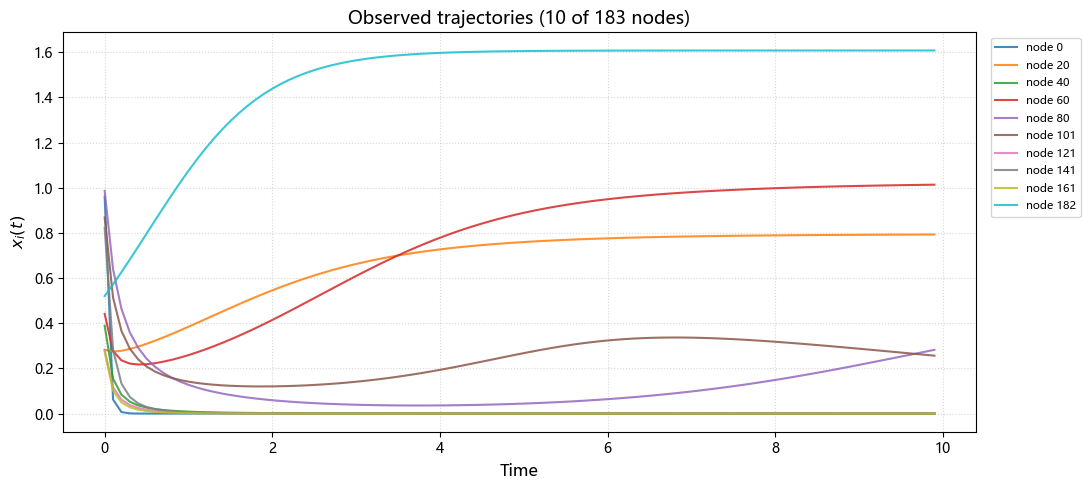

In [33]:
def plot_trajectory(X_obs, num_nodes=10, t_end=None, t_start=0,
                    dt=0.1, title=None, save_path=None):
    """
    Plot observed node trajectories.

    Parameters
    ----------
    X_obs     : (T, N) observed trajectory
    num_nodes : int    number of nodes to plot (uniformly sampled, default 10)
    t_end     : int or None  last time step to plot (default: full length)
    t_start   : int    first time step to plot (default: 0)
    dt        : float  time step size for x-axis scaling (default 0.1)
    title     : str or None
    save_path : str or None
    """
    T, N    = X_obs.shape
    t_end   = T if t_end is None else min(t_end, T)
    n_plot  = min(num_nodes, N)
    nodes   = np.linspace(0, N - 1, n_plot, dtype=int)
    colors  = [plt.cm.tab10(i % 10) for i in range(n_plot)]
    t_axis  = np.arange(t_start, t_end) * dt

    fig, ax = plt.subplots(figsize=(11, 5))

    for idx, node in enumerate(nodes):
        ax.plot(t_axis, X_obs[t_start:t_end, node],
                color=colors[idx], lw=1.5, alpha=0.85,
                label=f"node {node}")

    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel(r"$x_i(t)$", fontsize=12)
    ax.set_title(title or f"Observed trajectories ({n_plot} of {N} nodes)",
                 fontsize=13)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left',
              ncol=max(1, n_plot // 15))
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    _save_or_show(fig, save_path)

plot_trajectory(X_obs, num_nodes=10, t_end=100)

In [28]:
def check_convergence(A, model, T_max=2000, tol=1e-4, init_state=None):
    """检查 LV 是否在 T_max 步内收敛到稳态。"""
    if init_state is None:
        init_state = np.random.uniform(0.1, 1.0, A.shape[0])
    
    traj = model.simulate(A, T_steps=T_max, init_state=init_state)
    
    # 比较最后100步的变化幅度
    late_std = np.std(traj[-100:], axis=0).mean()
    converged = late_std < tol
    
    # 找到大致收敛时间
    diffs = np.abs(np.diff(traj, axis=0)).mean(axis=1)
    conv_step = np.where(diffs < tol)[0]
    conv_time = conv_step[0] if len(conv_step) > 0 else T_max
    
    print(f"收敛状态: {'是' if converged else '否'}")
    print(f"大致收敛步数: {conv_time}")
    print(f"末段波动幅度: {late_std:.2e}")
    return converged, conv_time

In [31]:
check_convergence(A_true, model, T_max=500, tol=1e-3, init_state=None)

收敛状态: 是
大致收敛步数: 60
末段波动幅度: 4.87e-05


(np.True_, np.int64(60))

In [18]:
'''
暂时用不到LASSO重构以及重构网络相关的实验
'''

# ==============================================================
# Cell 2 — Ground truth simulation & LASSO reconstruction
# ==============================================================
print("Simulating ground truth trajectory...")
X_obs = model.simulate(A_true, T_steps=T_total, init_state=x0, seed=SEED)

X_train   = X_obs[:T_train]
x0_pred   = X_obs[T_train]

print(f"\nReconstructing surrogate network from first {T_train} steps...")
A_hat, rho_hat = lasso_reconstruct_network(
    X_train, model, rho=None, val_ratio=0.2, n_alphas=20, threshold=0.01
)
print(f"A_hat edges  : {np.sum(np.abs(A_hat)  > 1e-5)}")
print(f"A_true edges : {np.sum(np.abs(A_true) > 1e-5)}")

Simulating ground truth trajectory...

Reconstructing surrogate network from first 20 steps...
重构模式：Auto（n_alphas=20）
重构完成，自动选择 rho 均值：3.0115e-02
A_hat edges  : 653
A_true edges : 2494


In [19]:
# ==============================================================
# Cell 3 — Dynamical subspace & A_eff
# ==============================================================
U_dyn = extract_dynamical_basis(X_obs, energy_threshold=0.98, min_k=N)
print(f"Dynamical subspace dimension k = {U_dyn.shape[1]}")

A_eff = compute_effective_matrix(A_true, U_dyn)
print(f"A_eff non-zero entries (|·|>1e-5): {np.sum(np.abs(A_eff) > 1e-5)}")

Dynamical subspace dimension k = 100
A_eff non-zero entries (|·|>1e-5): 33387


Sparsification v2: 2494 edges, epsilon=0.05
 step        edge     delta  decision  remaining
--------------------------------------------------
    0  (173,121)    0.0007    delete       2493
  124  ( 38, 92)    0.0180    delete       2369
  248  (111, 83)    0.0310    delete       2245
  361  (108,125)    0.0504      keep       2133
  371  ( 92, 67)    0.0500      keep       2124
  372  (127, 74)    0.0501      keep       2124
  373  (110,138)    0.0500      keep       2124
  374  (139,129)    0.0501      keep       2124
  376  (126, 74)    0.0502      keep       2123
  378  (140,130)    0.0506      keep       2122
  379  (139,126)    0.0501      keep       2122
  380  ( 49, 83)    0.0500      keep       2122
  381  (162,152)    0.0500      keep       2122
  382  ( 63,171)    0.0504      keep       2122
  384  (131, 76)    0.0500      keep       2121
  385  (112,130)    0.0508      keep       2121
  386  (121,125)    0.0501      keep       2121
  387  (105, 83)    0.0501      keep    

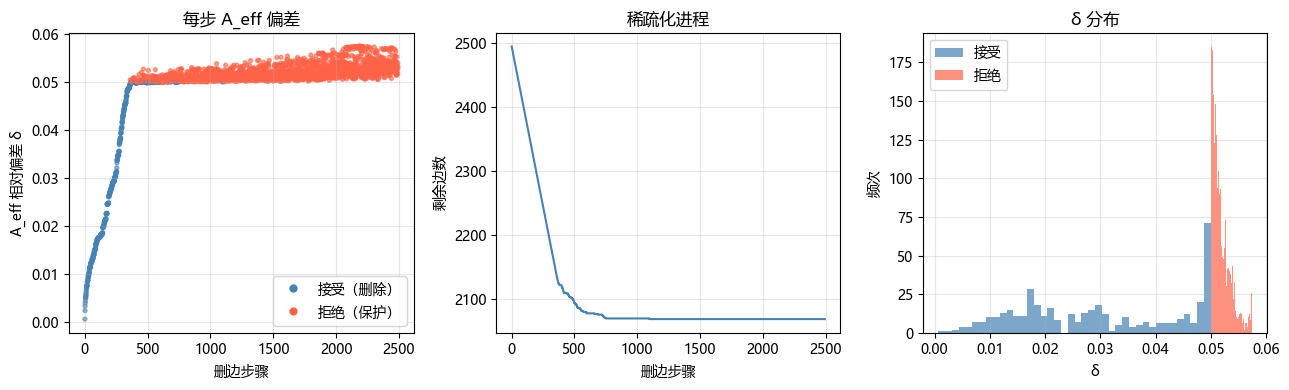

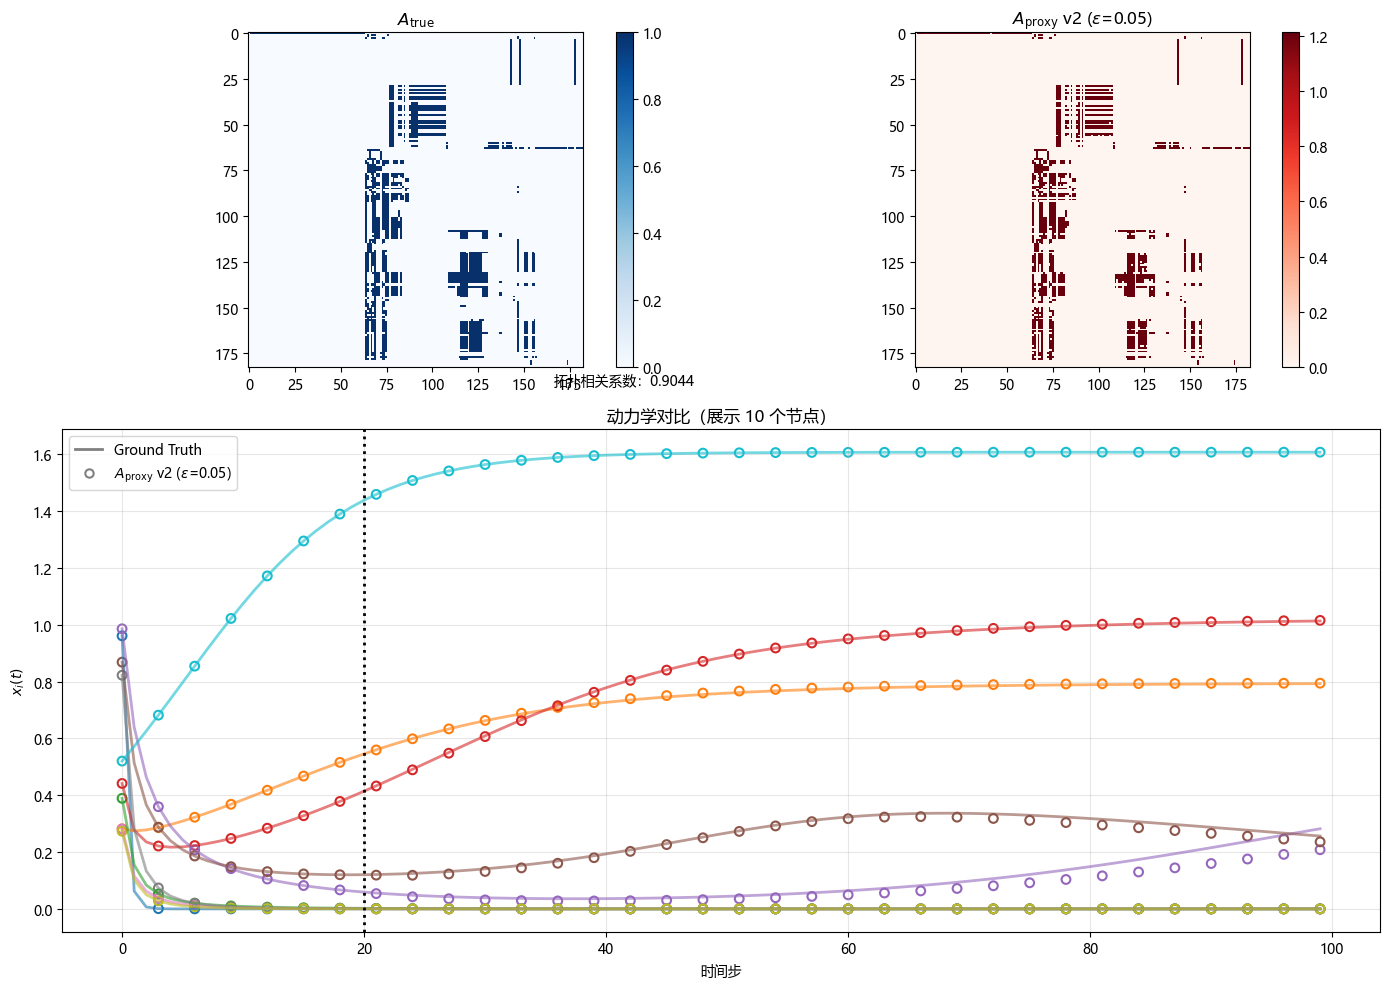

标签                                      全局 NRMSE
──────────────────────────────────────────────────
LASSO ($A_{\rm hat}$)                   0.164894
Algorithm v2 ($\varepsilon$=0.05)       0.064553


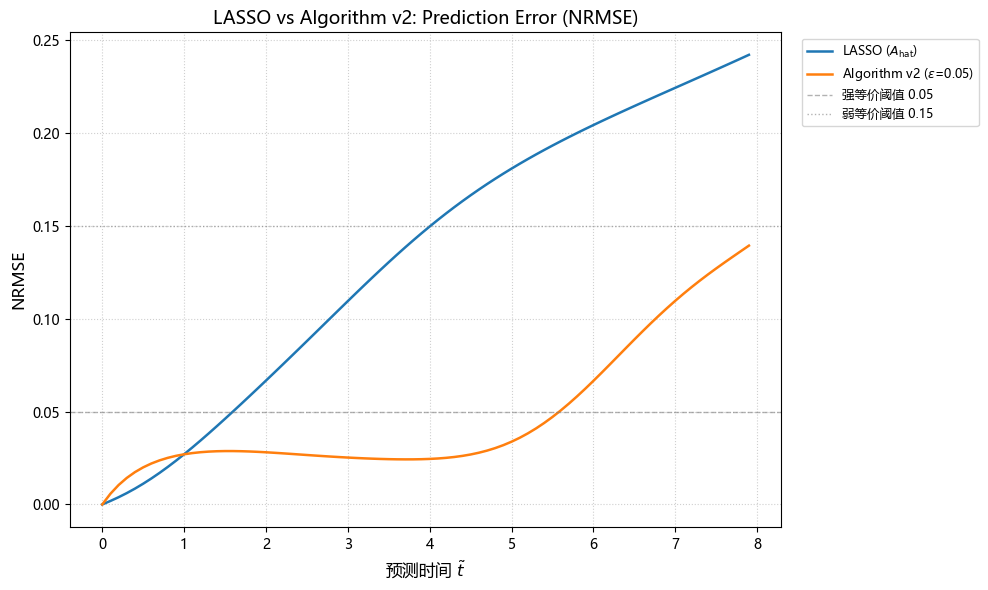

In [20]:
# ==============================================================
# Cell 4 — Algorithm v2: single run & diagnostics
# ==============================================================
A_proxy_v2, history_v2 = sparsify_network_v2(
    A_true, U_dyn, epsilon=0.05, verbose=True
)

# Diagnostic plot: delta scatter / edge count / delta histogram
plot_sparsification_path_v2(history_v2, save_path=None)

# Predict future trajectory with A_proxy_v2
steps_pred    = T_total - T_train
X_v2_future   = model.simulate(A_proxy_v2, T_steps=steps_pred, init_state=x0_pred)
X_v2_full     = np.vstack([X_train, X_v2_future])

# Trajectory comparison: A_true vs A_proxy_v2
plot_trajectory_comparison(
    A_true, A_proxy_v2, X_obs, X_v2_full,
    T_train_steps=T_train,
    num_nodes=10,
    name_proxy=r"$A_{\rm proxy}$ v2 ($\varepsilon$=0.05)",
    save_path=None
)

# LASSO vs Algorithm v2: NRMSE curves
X_hat_future = model.simulate(A_hat, T_steps=steps_pred, init_state=x0_pred)
X_hat_full   = np.vstack([X_train, X_hat_future])

plot_nrmse_comparison(
    X_obs,
    {
        "LASSO ($A_{\\rm hat}$)":          X_hat_full,
        r"Algorithm v2 ($\varepsilon$=0.05)": X_v2_full,
    },
    t_split=T_train,
    title="LASSO vs Algorithm v2: Prediction Error (NRMSE)",
    save_path=None
)

等价族构造完成：7 个稀疏度 × 5 个样本 = 35 个网络

     稀疏度     seed   δ(A_eff)    NRMSE      等价性
──────────────────────────────────────────────────
   0.300      342     0.8931   0.4254      不等价
   0.300      442     0.8927   0.4146      不等价
   0.300      542     0.8932   0.4282      不等价
   0.300      642     0.8925   0.3985      不等价
   0.300      742     0.8911   0.4005      不等价
   0.200      242     0.8799   0.4305      不等价
   0.200      342     0.8816   0.4265      不等价
   0.200      442     0.8820   0.4129      不等价
   0.200      542     0.8822   0.4136      不等价
   0.200      642     0.8804   0.3910      不等价
   0.150      192     0.8745   0.3963      不等价
   0.150      292     0.8732   0.4163      不等价
   0.150      392     0.8711   0.4055      不等价
   0.150      492     0.8724   0.3966      不等价
   0.150      592     0.8772   0.3945      不等价
   0.100      142     0.8652   0.4948      不等价
   0.100      242     0.8640   0.4807      不等价
   0.100      342     0.8672   0.4425      不等价
   0.100      442     0

C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_8036\942034452.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=lbls, patch_artist=True)


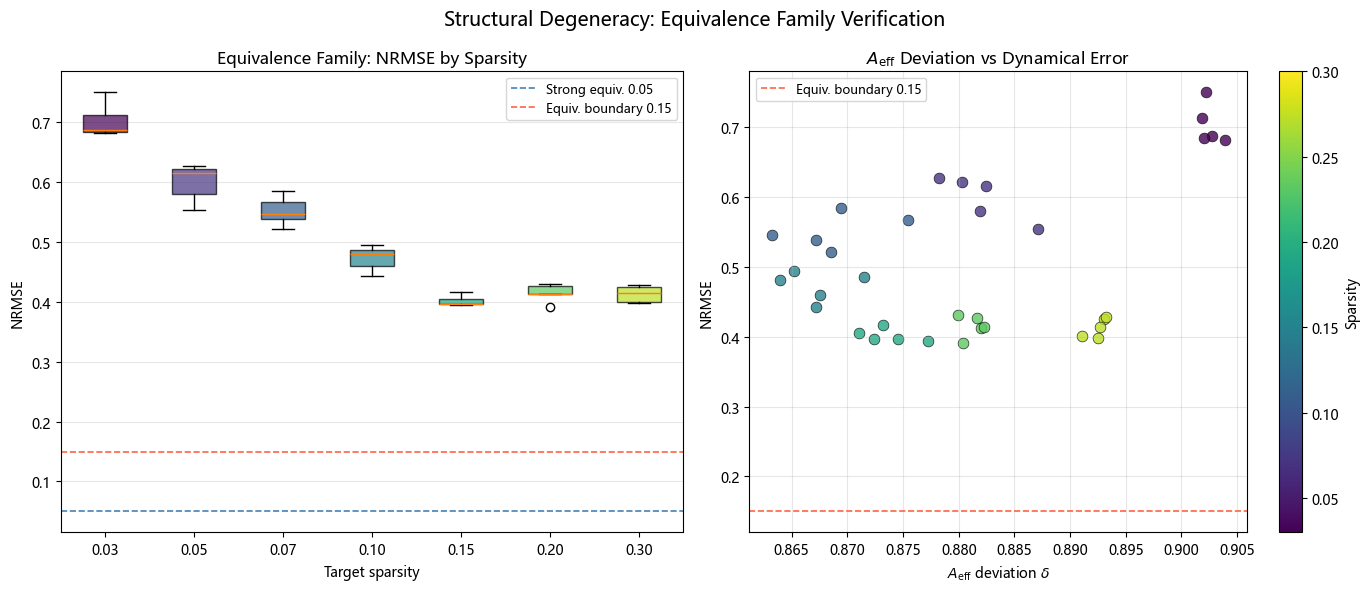

In [41]:
# ==============================================================
# Cell 5 — Equivalence family construction & verification
# Core experiment: can we construct structurally diverse networks
# that all share the same A_eff and drive the same dynamics?
# ==============================================================
A_eff_ref = compute_effective_matrix(A_true, U_dyn)
rho_ref   = float(np.max(np.abs(np.linalg.eigvals(A_true))))

# Sparsity levels to explore
# (fraction of edges relative to A_true; covers dense → sparse)
sparsity_levels = [0.30, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03]

family = build_equivalence_family(
    A_eff_ref, U_dyn,
    sparsity_levels=sparsity_levels,
    n_samples_per_level=5,
    rho_ref=rho_ref,
    seed=SEED
)

# Run dynamics on every member and compute NRMSE
results_family = verify_equivalence_family(
    family, model, X_obs, T_train_steps=T_train,
    T_sim=500, seed=SEED
)

# Visualise: boxplot by sparsity + delta vs NRMSE scatter
plot_equivalence_family(
    results_family,
    nrmse_threshold=0.15,
    save_path=None
)

A_true order parameter Phi = 0.3427

Epsilon percolation scan: 25 points
     eps  sparsity    delta    NRMSE   eps_mac    align       PR   rho_r
------------------------------------------------------------------------
  0.0100    0.9771   0.0455   0.0059    0.0012   0.9969    13.36  1.0000
  0.0164    0.9415   0.1355   0.0159    0.0068   0.9804    13.40  1.0000
  0.0229    0.9058   0.1392   0.0164    0.0139   0.9669    13.43  1.0000
  0.0293    0.8813   0.1714   0.0198    0.0189   0.9563    13.49  1.0000
  0.0357    0.8669   0.1474   0.0585    0.0653   0.9469    13.49  1.0000
  0.0421    0.8549   0.2090   0.0564    0.0646   0.9438    13.55  1.0000
  0.0486    0.8348   0.1864   0.0636    0.0948   0.9265    13.57  1.0000
  0.0550    0.8123   0.2048   0.1103    0.1152   0.9076    13.63  1.0000
  0.0614    0.7979   0.2054   0.1112    0.1343   0.8914    13.70  1.0000
  0.0679    0.7871   0.2128   0.1112    0.1307   0.8869    13.78  1.0000
  0.0743    0.7791   0.2681   0.1208    0.1607   0.

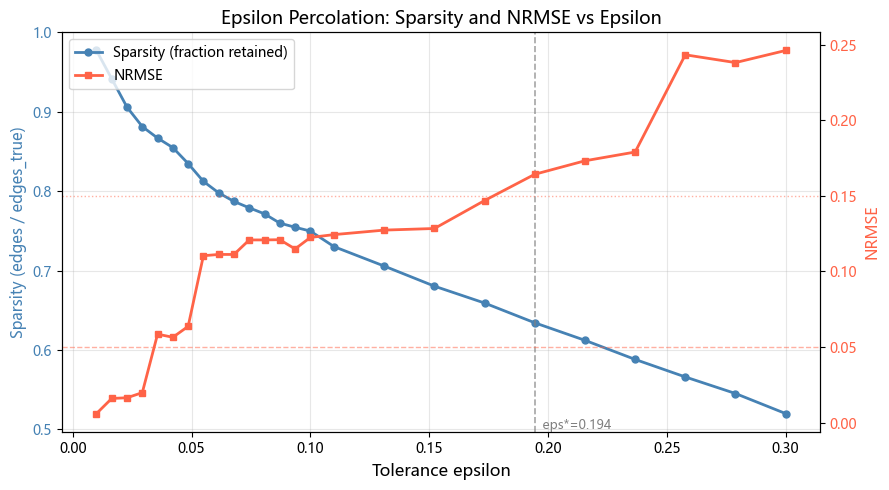

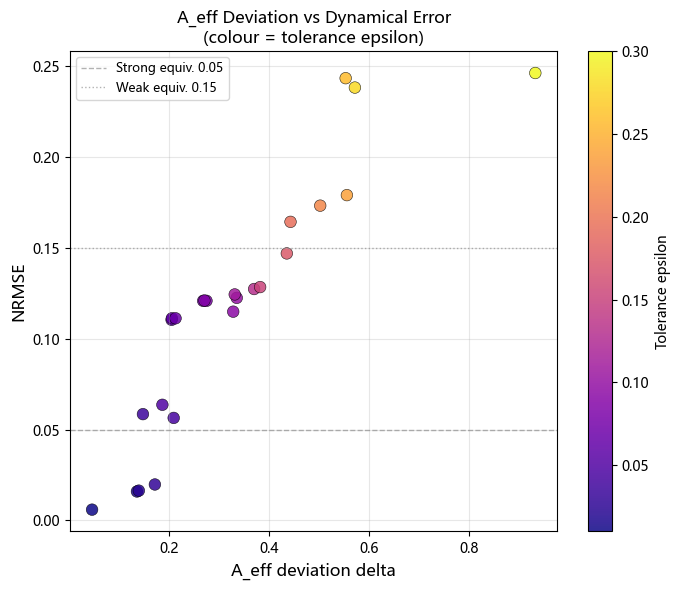

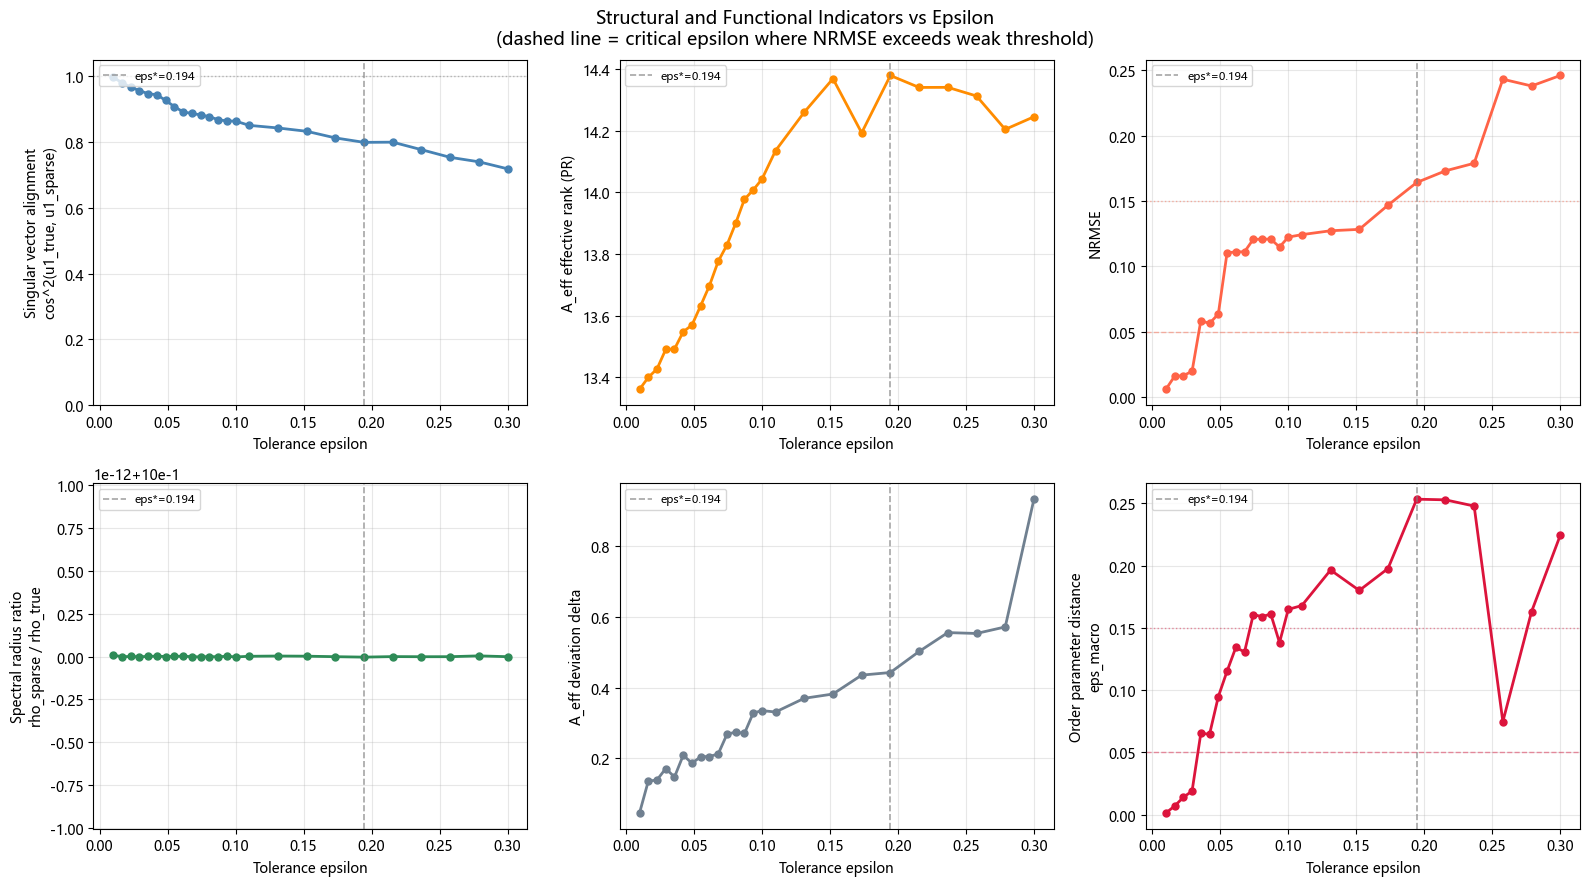

In [38]:
# ==============================================================
# Cell 6 — Epsilon percolation scan
# Sweep epsilon from tight to loose; record sparsity, delta, NRMSE.
# Identifies the critical epsilon epsilon* where NRMSE jumps.
# ==============================================================
# 定义 epsilon 扫描范围
epsilon_range = np.concatenate([
    np.linspace(0.01, 0.10, 15),
    np.linspace(0.11, 0.30, 10),
])

# 运行扫描（包含序参量距离）
perc_records = scan_epsilon_percolation(
    A_true, U_dyn, model, X_obs,
    T_train_steps=T_train,
    epsilon_range=np.sort(epsilon_range),
    T_sim=500,
    T_steady=150,
    seed=SEED,
    verbose=True
)

# 画图
plot_epsilon_percolation(
    perc_records,
    nrmse_strong=0.05,
    nrmse_weak=0.15,
    save_path_main=None,
    save_path_scatter=None,
    save_path_indicators=None
)

C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:127: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig1.tight_layout()
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:127: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig1.tight_layout()
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:128: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig1.savefig('fig1_percolation_overview.png', bbox_inches='tight')
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:128: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig1.savefig('fig1_percolation_overview.png', bbox_inches='tight')
C:\Users\liu.xuanc\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(b

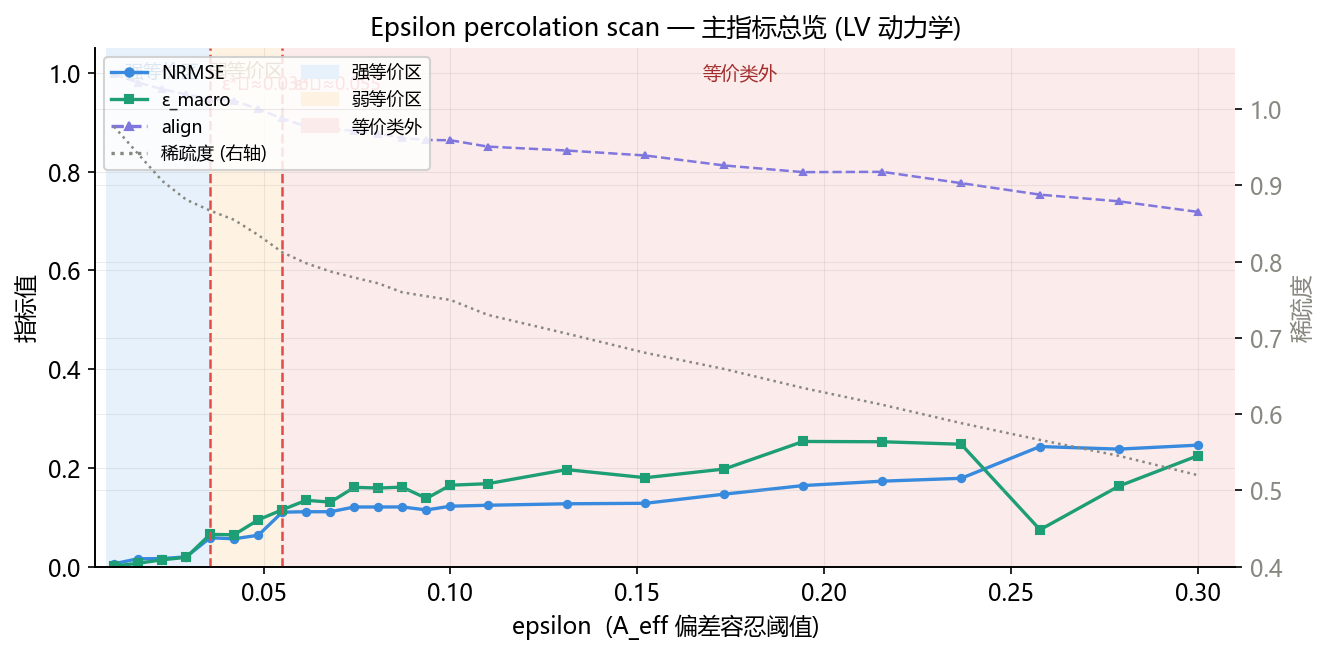

图1 已保存: fig1_percolation_overview.png


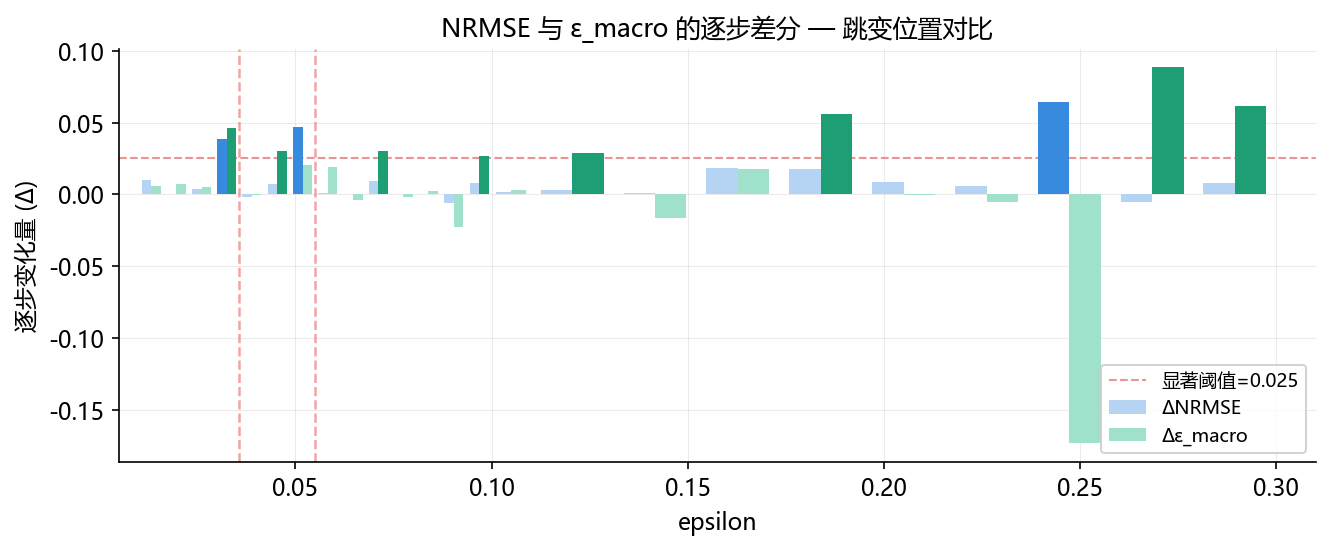

图2 已保存: fig2_diff_comparison.png


C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:204: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig3.tight_layout()
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:204: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig3.tight_layout()
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:205: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig3.savefig('fig3_scatter_align_emac.png', bbox_inches='tight')
C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2200\1017101900.py:205: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig3.savefig('fig3_scatter_align_emac.png', bbox_inches='tight')


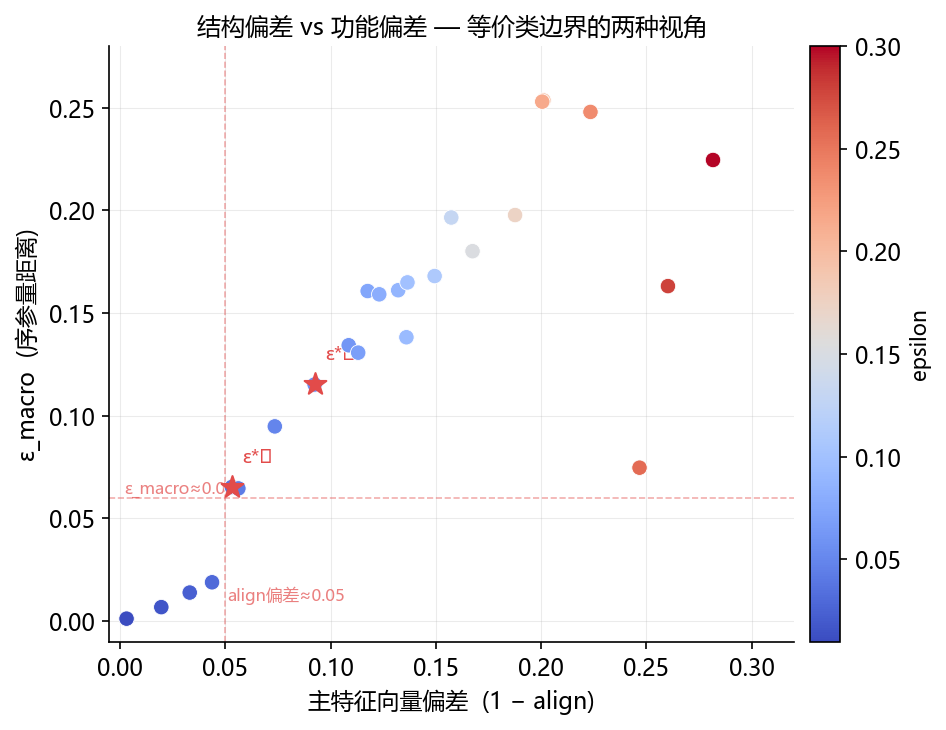

图3 已保存: fig3_scatter_align_emac.png


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ──────────────────────────────────────────────
# 数据
# ──────────────────────────────────────────────
raw = np.array([
    [0.0100, 0.9771, 0.0455, 0.0059, 0.0012, 0.9969, 13.36],
    [0.0164, 0.9415, 0.1355, 0.0159, 0.0068, 0.9804, 13.40],
    [0.0229, 0.9058, 0.1392, 0.0164, 0.0139, 0.9669, 13.43],
    [0.0293, 0.8813, 0.1714, 0.0198, 0.0189, 0.9563, 13.49],
    [0.0357, 0.8669, 0.1474, 0.0585, 0.0653, 0.9469, 13.49],
    [0.0421, 0.8549, 0.2090, 0.0564, 0.0646, 0.9438, 13.55],
    [0.0486, 0.8348, 0.1864, 0.0636, 0.0948, 0.9265, 13.57],
    [0.0550, 0.8123, 0.2048, 0.1103, 0.1152, 0.9076, 13.63],
    [0.0614, 0.7979, 0.2054, 0.1112, 0.1343, 0.8914, 13.70],
    [0.0679, 0.7871, 0.2128, 0.1112, 0.1307, 0.8869, 13.78],
    [0.0743, 0.7791, 0.2681, 0.1208, 0.1607, 0.8824, 13.83],
    [0.0807, 0.7715, 0.2747, 0.1208, 0.1591, 0.8769, 13.90],
    [0.0871, 0.7598, 0.2706, 0.1209, 0.1611, 0.8679, 13.98],
    [0.0936, 0.7546, 0.3283, 0.1148, 0.1382, 0.8640, 14.01],
    [0.1000, 0.7498, 0.3353, 0.1224, 0.1649, 0.8635, 14.04],
    [0.1100, 0.7302, 0.3313, 0.1243, 0.1680, 0.8506, 14.13],
    [0.1311, 0.7057, 0.3701, 0.1273, 0.1965, 0.8427, 14.26],
    [0.1522, 0.6804, 0.3822, 0.1283, 0.1801, 0.8326, 14.37],
    [0.1733, 0.6592, 0.4357, 0.1468, 0.1977, 0.8124, 14.19],
    [0.1944, 0.6343, 0.4431, 0.1642, 0.2535, 0.7989, 14.38],
    [0.2156, 0.6123, 0.5025, 0.1731, 0.2529, 0.7995, 14.34],
    [0.2367, 0.5882, 0.5560, 0.1789, 0.2479, 0.7766, 14.34],
    [0.2578, 0.5662, 0.5535, 0.2432, 0.0747, 0.7533, 14.31],
    [0.2789, 0.5453, 0.5720, 0.2380, 0.1631, 0.7398, 14.20],
    [0.3000, 0.5200, 0.9334, 0.2460, 0.2245, 0.7184, 14.24],
])

eps    = raw[:, 0]
sp     = raw[:, 1]
delta  = raw[:, 2]
nrmse  = raw[:, 3]
emac   = raw[:, 4]
align  = raw[:, 5]

# 跳变点位置（索引）
J1, J2 = 4, 7
EPS_J1, EPS_J2 = eps[J1], eps[J2]

# 颜色定义
C_NRMSE = '#378ADD'
C_EMAC  = '#1D9E75'
C_ALIGN = '#7F77DD'
C_SP    = '#888780'
C_J     = '#E24B4A'
C_Z1    = '#E6F1FB'   # 强等价区底色
C_Z2    = '#FEF3E2'   # 弱等价区底色
C_Z3    = '#FCEBEB'   # 等价类外底色

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.6,
    'figure.dpi': 150,
})


# ══════════════════════════════════════════════
# 图1：主指标总览
# ══════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(9, 4.5))
ax1r = ax1.twinx()

# 背景分区
ax1.axvspan(eps[0]-0.002, EPS_J1, alpha=1, color=C_Z1, zorder=0, label='_')
ax1.axvspan(EPS_J1, EPS_J2,       alpha=1, color=C_Z2, zorder=0, label='_')
ax1.axvspan(EPS_J2, eps[-1]+0.01, alpha=1, color=C_Z3, zorder=0, label='_')

# 分区标签
y_lab = 0.97
for x_c, txt, col in [
    ((eps[0]+EPS_J1)/2,     '强等价区', '#185FA5'),
    ((EPS_J1+EPS_J2)/2,     '弱等价区', '#854F0B'),
    ((EPS_J2+eps[-1])/2,    '等价类外', '#A32D2D'),
]:
    ax1.text(x_c, y_lab, txt, ha='center', va='top',
             transform=ax1.get_xaxis_transform(),
             fontsize=9, color=col)

# 跳变线
for xv, lbl in [(EPS_J1, f'ε*₁≈{EPS_J1:.3f}'), (EPS_J2, f'ε*₂≈{EPS_J2:.3f}')]:
    ax1.axvline(xv, color=C_J, lw=1.2, ls='--', zorder=3)
    ax1.text(xv+0.003, 0.92, lbl, transform=ax1.get_xaxis_transform(),
             fontsize=8.5, color=C_J)

# 曲线
ax1.plot(eps, nrmse, color=C_NRMSE, marker='o', ms=3.5, label='NRMSE')
ax1.plot(eps, emac,  color=C_EMAC,  marker='s', ms=3.5, label='ε_macro')
ax1.plot(eps, align, color=C_ALIGN, marker='^', ms=3,
         ls='--', lw=1.2, label='align (主特征向量)')
ax1r.plot(eps, sp,   color=C_SP,    marker='',  ms=0,
          ls=':', lw=1.2, label='稀疏度 (右轴)')

ax1.set_xlabel('epsilon  (A_eff 偏差容忍阈值)')
ax1.set_ylabel('指标值')
ax1r.set_ylabel('稀疏度', color=C_SP)
ax1r.tick_params(axis='y', labelcolor=C_SP)
ax1r.set_ylim(0.4, 1.08)
ax1.set_ylim(0, 1.05)
ax1.set_xlim(eps[0]-0.005, eps[-1]+0.01)

handles = [
    Line2D([0],[0], color=C_NRMSE, marker='o', ms=4, label='NRMSE'),
    Line2D([0],[0], color=C_EMAC,  marker='s', ms=4, label='ε_macro'),
    Line2D([0],[0], color=C_ALIGN, marker='^', ms=4, ls='--', label='align'),
    Line2D([0],[0], color=C_SP,    ls=':',           label='稀疏度 (右轴)'),
    mpatches.Patch(color=C_Z1, label='强等价区'),
    mpatches.Patch(color=C_Z2, label='弱等价区'),
    mpatches.Patch(color=C_Z3, label='等价类外'),
]
ax1.legend(handles=handles, fontsize=8.5, loc='upper left',
           framealpha=0.85, ncol=2)
ax1.set_title('Epsilon percolation scan — 主指标总览 (LV 动力学)', fontsize=12)
fig1.tight_layout()
fig1.savefig('fig1_percolation_overview.png', bbox_inches='tight')
plt.show()
print('图1 已保存: fig1_percolation_overview.png')


# ══════════════════════════════════════════════
# 图2：NRMSE 与 ε_macro 的逐步差分对比
# ══════════════════════════════════════════════
dnrmse = np.diff(nrmse)
demac  = np.diff(emac)
x_mid  = (eps[:-1] + eps[1:]) / 2
THRESH = 0.025

fig2, ax2 = plt.subplots(figsize=(9, 3.8))
w = np.diff(eps) * 0.38

ax2.bar(x_mid - w/2, dnrmse, width=w,
        color=[C_NRMSE if v > THRESH else '#B5D4F4' for v in dnrmse],
        label='ΔNRMSE', zorder=3)
ax2.bar(x_mid + w/2, demac,  width=w,
        color=[C_EMAC  if v > THRESH else '#9FE1CB' for v in demac],
        label='Δε_macro', zorder=3)

ax2.axhline(THRESH, color=C_J, lw=1, ls='--', alpha=0.6, label=f'显著阈值={THRESH}')
for xv in [EPS_J1, EPS_J2]:
    ax2.axvline(xv, color=C_J, lw=1.2, ls='--', alpha=0.5)

ax2.set_xlabel('epsilon')
ax2.set_ylabel('逐步变化量 (Δ)')
ax2.set_xlim(eps[0]-0.005, eps[-1]+0.01)
ax2.legend(fontsize=9, framealpha=0.85)
ax2.set_title('NRMSE 与 ε_macro 的逐步差分 — 跳变位置对比', fontsize=12)
fig2.tight_layout()
fig2.savefig('fig2_diff_comparison.png', bbox_inches='tight')
plt.show()
print('图2 已保存: fig2_diff_comparison.png')


# ══════════════════════════════════════════════
# 图3：ε_macro 与 align 的散点关系
# ══════════════════════════════════════════════
align_dev = 1 - align   # 偏差形式，方向与 ε_macro 一致

# 颜色：按 epsilon 从小（蓝）到大（红）渐变
cmap   = plt.cm.coolwarm
norm_c = plt.Normalize(eps.min(), eps.max())
colors_sc = cmap(norm_c(eps))

fig3, ax3 = plt.subplots(figsize=(6.5, 5))

# 背景分区（纵向：ε_macro 跳变后 > 0.06）
ax3.axhline(0.06,  color=C_J, lw=0.8, ls='--', alpha=0.45)
ax3.axvline(0.05,  color=C_J, lw=0.8, ls='--', alpha=0.45)
ax3.text(0.051, 0.01, 'align偏差≈0.05', fontsize=8, color=C_J, alpha=0.7)
ax3.text(0.002, 0.062, 'ε_macro≈0.06', fontsize=8, color=C_J, alpha=0.7)

sc = ax3.scatter(align_dev, emac, c=eps, cmap='coolwarm',
                 s=55, zorder=4, edgecolors='white', lw=0.4)

# 标注两个跳变点
for idx, lbl in [(J1, 'ε*₁'), (J2, 'ε*₂')]:
    ax3.scatter(align_dev[idx], emac[idx],
                s=120, marker='*', color=C_J, zorder=5)
    ax3.annotate(lbl,
                 xy=(align_dev[idx], emac[idx]),
                 xytext=(align_dev[idx]+0.005, emac[idx]+0.012),
                 fontsize=9, color=C_J)

cbar = fig3.colorbar(sc, ax=ax3, pad=0.02)
cbar.set_label('epsilon', fontsize=10)

ax3.set_xlabel('主特征向量偏差  (1 − align)')
ax3.set_ylabel('ε_macro  (序参量距离)')
ax3.set_xlim(-0.005, 0.32)
ax3.set_ylim(-0.01, 0.28)
ax3.set_title('结构偏差 vs 功能偏差 — 等价类边界的两种视角', fontsize=11.5)
fig3.tight_layout()
fig3.savefig('fig3_scatter_align_emac.png', bbox_inches='tight')
plt.show()
print('图3 已保存: fig3_scatter_align_emac.png')

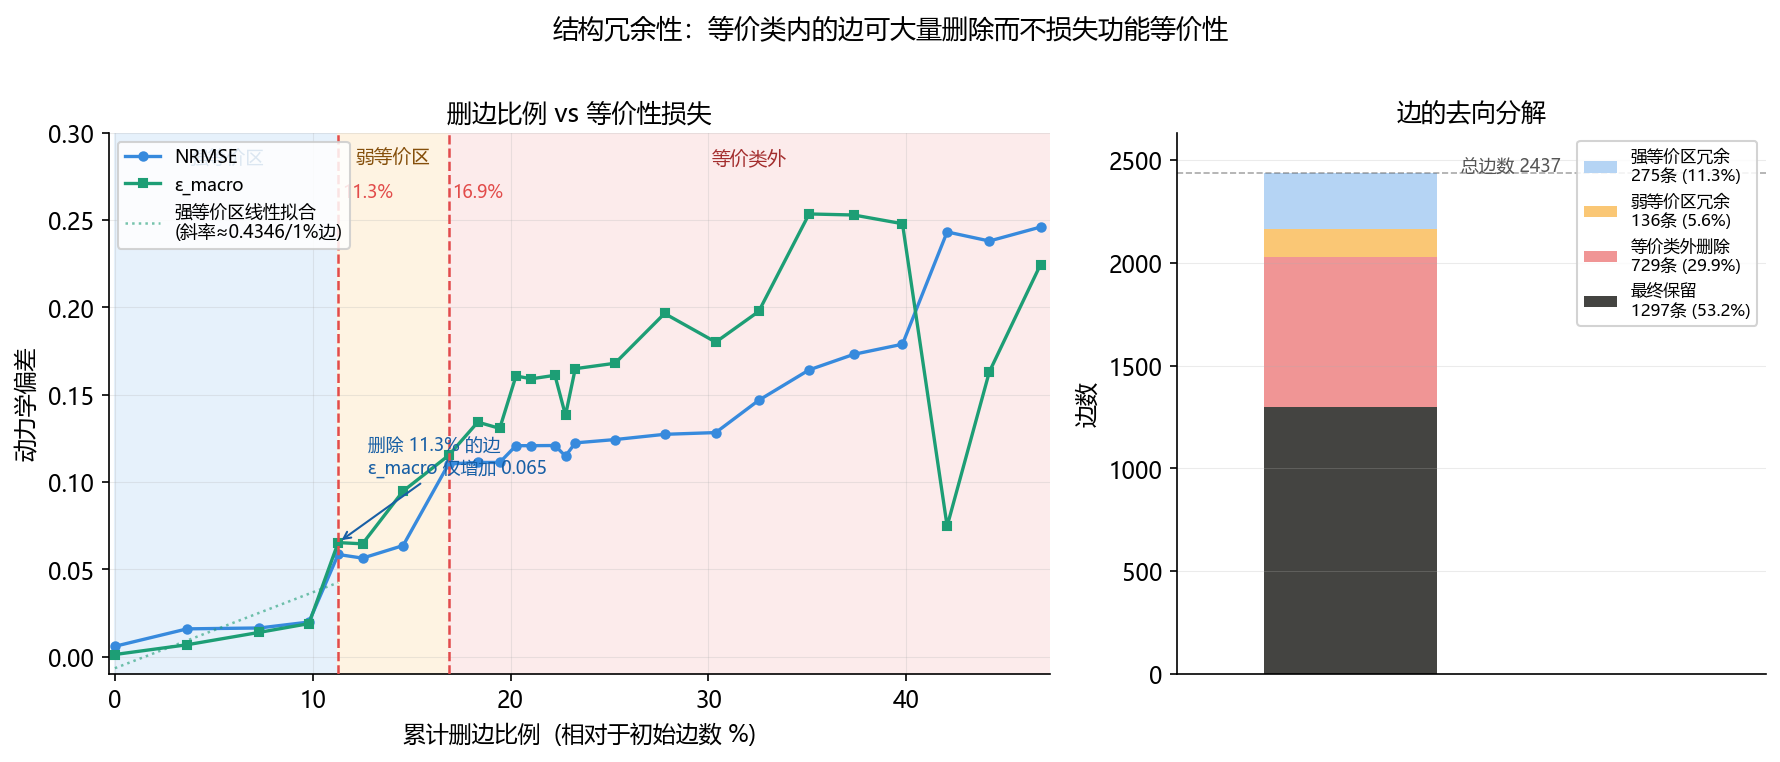

图4 已保存: fig4_redundancy.png


In [42]:
raw = np.array([
    [0.0100, 0.9771, 0.0455, 0.0059, 0.0012, 0.9969, 13.36, 2437],
    [0.0164, 0.9415, 0.1355, 0.0159, 0.0068, 0.9804, 13.40, 2348],
    [0.0229, 0.9058, 0.1392, 0.0164, 0.0139, 0.9669, 13.43, 2259],
    [0.0293, 0.8813, 0.1714, 0.0198, 0.0189, 0.9563, 13.49, 2198],
    [0.0357, 0.8669, 0.1474, 0.0585, 0.0653, 0.9469, 13.49, 2162],
    [0.0421, 0.8549, 0.2090, 0.0564, 0.0646, 0.9438, 13.55, 2132],
    [0.0486, 0.8348, 0.1864, 0.0636, 0.0948, 0.9265, 13.57, 2082],
    [0.0550, 0.8123, 0.2048, 0.1103, 0.1152, 0.9076, 13.63, 2026],
    [0.0614, 0.7979, 0.2054, 0.1112, 0.1343, 0.8914, 13.70, 1990],
    [0.0679, 0.7871, 0.2128, 0.1112, 0.1307, 0.8869, 13.78, 1963],
    [0.0743, 0.7791, 0.2681, 0.1208, 0.1607, 0.8824, 13.83, 1943],
    [0.0807, 0.7715, 0.2747, 0.1208, 0.1591, 0.8769, 13.90, 1924],
    [0.0871, 0.7598, 0.2706, 0.1209, 0.1611, 0.8679, 13.98, 1895],
    [0.0936, 0.7546, 0.3283, 0.1148, 0.1382, 0.8640, 14.01, 1882],
    [0.1000, 0.7498, 0.3353, 0.1224, 0.1649, 0.8635, 14.04, 1870],
    [0.1100, 0.7302, 0.3313, 0.1243, 0.1680, 0.8506, 14.13, 1821],
    [0.1311, 0.7057, 0.3701, 0.1273, 0.1965, 0.8427, 14.26, 1760],
    [0.1522, 0.6804, 0.3822, 0.1283, 0.1801, 0.8326, 14.37, 1697],
    [0.1733, 0.6592, 0.4357, 0.1468, 0.1977, 0.8124, 14.19, 1644],
    [0.1944, 0.6343, 0.4431, 0.1642, 0.2535, 0.7989, 14.38, 1582],
    [0.2156, 0.6123, 0.5025, 0.1731, 0.2529, 0.7995, 14.34, 1527],
    [0.2367, 0.5882, 0.5560, 0.1789, 0.2479, 0.7766, 14.34, 1467],
    [0.2578, 0.5662, 0.5535, 0.2432, 0.0747, 0.7533, 14.31, 1412],
    [0.2789, 0.5453, 0.5720, 0.2380, 0.1631, 0.7398, 14.20, 1360],
    [0.3000, 0.5200, 0.9334, 0.2460, 0.2245, 0.7184, 14.24, 1297],
])

eps   = raw[:, 0]
sp    = raw[:, 1]
nrmse = raw[:, 3]
emac  = raw[:, 4]
edges = raw[:, 7]

E0      = edges[0]          # 起始边数（最稠密时）
J1, J2  = 4, 7
EPS_J1  = eps[J1]
EPS_J2  = eps[J2]

# 删边比例：相对于起始状态删掉了多少
edges_removed_pct = (E0 - edges) / E0 * 100

# "冗余度"：在等价性尚未损失的区间内，每删除1%的边引起的 ε_macro 增量
# 用强等价区内的平均斜率估计
mask_equiv = np.arange(len(eps)) <= J1
slope_equiv = np.polyfit(edges_removed_pct[mask_equiv],
                         emac[mask_equiv], 1)[0]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'figure.dpi': 150,
})

C_NRMSE = '#378ADD'
C_EMAC  = '#1D9E75'
C_J     = '#E24B4A'
C_Z1    = '#E6F1FB'
C_Z2    = '#FEF3E2'
C_Z3    = '#FCEBEB'

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          gridspec_kw={'width_ratios': [1.6, 1]})


# ── 左图：删边比例 vs 等价性损失 ──────────────────────────
ax = axes[0]

# 背景分区（按跳变点对应的删边比例划分）
er_j1 = edges_removed_pct[J1]
er_j2 = edges_removed_pct[J2]
xmax  = edges_removed_pct[-1] + 0.5

ax.axvspan(0, er_j1,       alpha=1, color=C_Z1, zorder=0)
ax.axvspan(er_j1, er_j2,   alpha=1, color=C_Z2, zorder=0)
ax.axvspan(er_j2, xmax,    alpha=1, color=C_Z3, zorder=0)

# 分区标签
for xc, txt, col in [
    (er_j1/2,            '强等价区', '#185FA5'),
    ((er_j1+er_j2)/2,    '弱等价区', '#854F0B'),
    ((er_j2+xmax)/2,     '等价类外', '#A32D2D'),
]:
    ax.text(xc, 0.97, txt, ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=9, color=col)

# 跳变线
for xv, lbl in [(er_j1, f'{er_j1:.1f}%'), (er_j2, f'{er_j2:.1f}%')]:
    ax.axvline(xv, color=C_J, lw=1.2, ls='--', zorder=3)
    ax.text(xv + 0.2, 0.88, lbl, transform=ax.get_xaxis_transform(),
            fontsize=8.5, color=C_J)

# 曲线
ax.plot(edges_removed_pct, nrmse, color=C_NRMSE,
        marker='o', ms=4, label='NRMSE')
ax.plot(edges_removed_pct, emac,  color=C_EMAC,
        marker='s', ms=4, label='ε_macro')

# 强等价区内的线性拟合（展示极低斜率）
x_fit = np.linspace(0, er_j1, 50)
y_fit = np.polyval(np.polyfit(edges_removed_pct[mask_equiv],
                               emac[mask_equiv], 1), x_fit)
ax.plot(x_fit, y_fit, color=C_EMAC, ls=':', lw=1.2, alpha=0.6,
        label=f'强等价区线性拟合\n(斜率≈{slope_equiv*100:.4f}/1%边)')

# 标注关键数字
ax.annotate(
    f'删除 {er_j1:.1f}% 的边\nε_macro 仅增加 {emac[J1]:.3f}',
    xy=(er_j1, emac[J1]),
    xytext=(er_j1 + 1.5, emac[J1] + 0.04),
    fontsize=8.5, color='#185FA5',
    arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1),
)

ax.set_xlim(-0.3, xmax)
ax.set_ylim(-0.01, 0.30)
ax.set_xlabel('累计删边比例  (相对于初始边数 %)')
ax.set_ylabel('动力学偏差')
ax.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
ax.set_title('删边比例 vs 等价性损失', fontsize=12)


# ── 右图：冗余边示意（堆积条形图）──────────────────────────
ax2 = axes[1]

# 三个区间各自删掉了多少边（绝对数）
e_start  = E0
e_at_j1  = edges[J1]
e_at_j2  = edges[J2]
e_at_end = edges[-1]

removed_z1 = e_start  - e_at_j1   # 强等价区内删除的边
removed_z2 = e_at_j1  - e_at_j2   # 弱等价区内删除的边
removed_z3 = e_at_j2  - e_at_end  # 等价类外删除的边
kept       = e_at_end              # 最终保留的边

categories = ['初始网络', '强等价区\n删除', '弱等价区\n删除', '等价类外\n删除', '最终保留']
values     = [0, removed_z1, removed_z2, removed_z3, kept]

bar_colors = ['#B5D4F4', C_Z1[:-1], C_Z2[:-1], '#FCEBEB', '#444441']
bar_colors = ['#aaaaaa', '#B5D4F4', '#FAC775', '#F09595', '#444441']

# 水平条形图：展示各部分占总边数的比例
fracs = [e_start, removed_z1, removed_z2, removed_z3, kept]
labels_bar = [
    f'初始总边数\n{int(e_start)}',
    f'强等价区冗余边\n{int(removed_z1)}条 ({removed_z1/e_start*100:.1f}%)',
    f'弱等价区冗余边\n{int(removed_z2)}条 ({removed_z2/e_start*100:.1f}%)',
    f'等价类外删除\n{int(removed_z3)}条 ({removed_z3/e_start*100:.1f}%)',
    f'最终保留\n{int(kept)}条 ({kept/e_start*100:.1f}%)',
]

# 用嵌套条形图展示边的去向
bottoms = [0, 0, removed_z1, removed_z1+removed_z2, removed_z1+removed_z2+removed_z3]
bar_c   = ['#B5D4F4', '#B5D4F4', '#FAC775', '#F09595', '#444441']
bar_lab = ['_', '强等价区冗余', '弱等价区冗余', '等价类外删除', '最终保留']
bar_val = [0, removed_z1, removed_z2, removed_z3, kept]

# 单根竖向堆积条
ax2.bar(0, removed_z1, bottom=kept+removed_z3+removed_z2,
        color='#B5D4F4', width=0.5, label=f'强等价区冗余\n{int(removed_z1)}条 ({removed_z1/e_start*100:.1f}%)')
ax2.bar(0, removed_z2, bottom=kept+removed_z3,
        color='#FAC775', width=0.5, label=f'弱等价区冗余\n{int(removed_z2)}条 ({removed_z2/e_start*100:.1f}%)')
ax2.bar(0, removed_z3, bottom=kept,
        color='#F09595', width=0.5, label=f'等价类外删除\n{int(removed_z3)}条 ({removed_z3/e_start*100:.1f}%)')
ax2.bar(0, kept, bottom=0,
        color='#444441', width=0.5, label=f'最终保留\n{int(kept)}条 ({kept/e_start*100:.1f}%)')

# 标注总边数
ax2.axhline(e_start, color='#555', lw=0.8, ls='--', alpha=0.5)
ax2.text(0.32, e_start + 10, f'总边数 {int(e_start)}', fontsize=8.5, color='#555')

ax2.set_xlim(-0.5, 1.2)
ax2.set_ylim(0, e_start * 1.08)
ax2.set_xticks([])
ax2.set_ylabel('边数')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax2.set_title('边的去向分解', fontsize=12)

fig.suptitle('结构冗余性：等价类内的边可大量删除而不损失功能等价性',
             fontsize=12.5, y=1.01)
fig.tight_layout()
fig.savefig('fig4_redundancy.png', bbox_inches='tight')
plt.show()
print('图4 已保存: fig4_redundancy.png')

稀疏化算法测试

Selected epsilon: 0.2578  (sparsity: 0.566, NRMSE: 0.2432)

Node-level steady-state comparison:
  Pearson correlation : 0.7194
  Mean  (proxy / true): 0.3891 / 0.3467
  Std   (proxy / true): 0.5363  / 0.5359
  eps_macro           : 0.1225


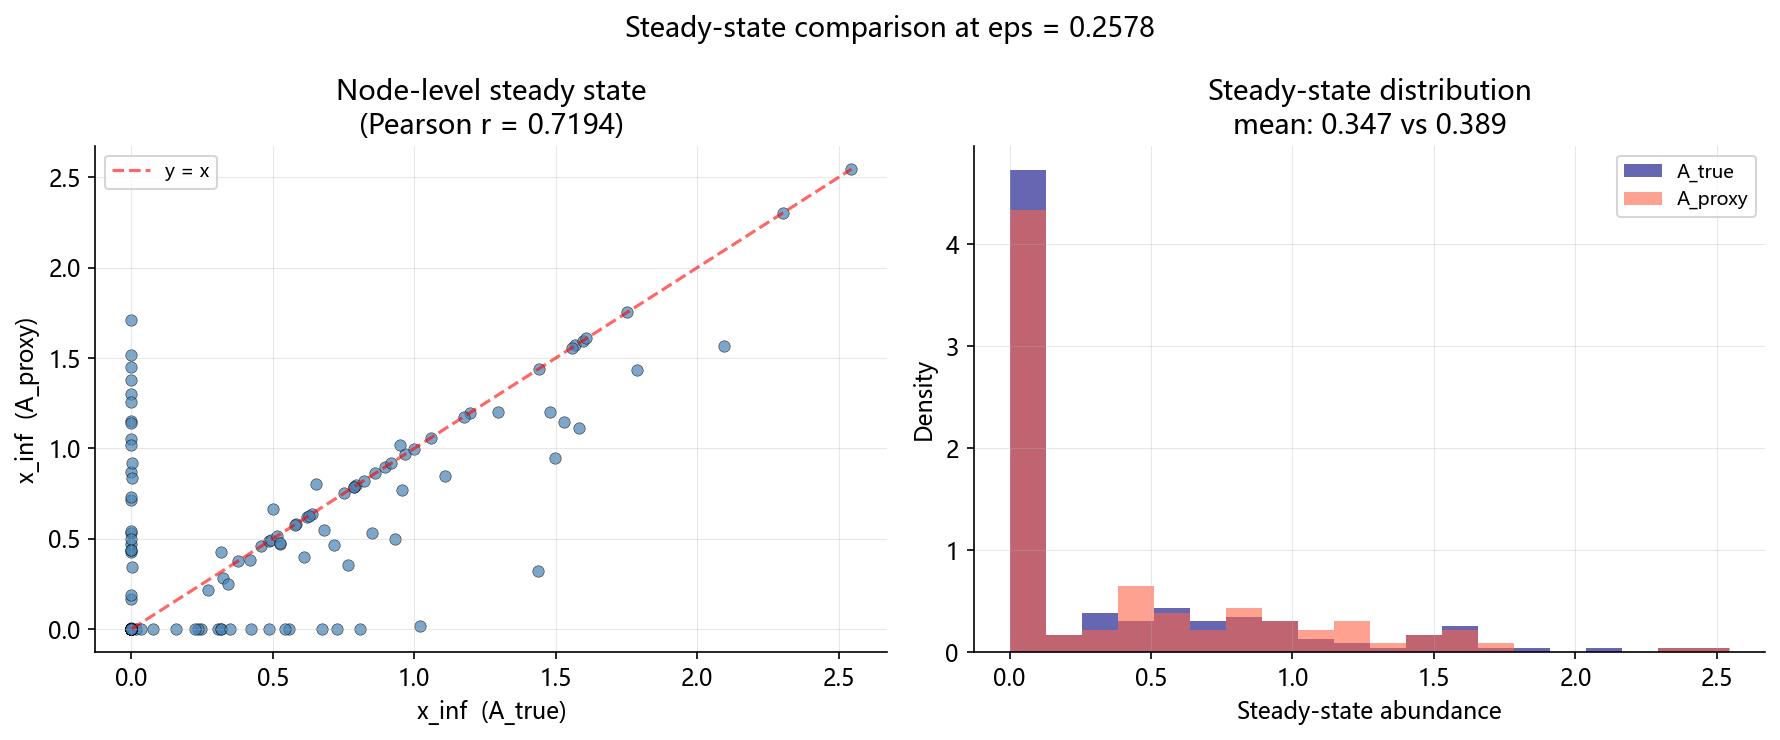

In [45]:
# 从 perc_records 里找到 eps 最接近 0.2578 的那个 A_proxy
target_eps = 0.2578
rec = min(perc_records, key=lambda r: abs(r['epsilon'] - target_eps))
A_proxy_0257 = rec['A_sparse']
print(f"Selected epsilon: {rec['epsilon']:.4f}  "
      f"(sparsity: {rec['sparsity']:.3f}, NRMSE: {rec['nrmse']:.4f})")

# 统一初始条件
init_state = X_obs[0]

# 计算稳态序参量
phi_proxy, x_inf_proxy = compute_order_parameter_LV(
    A_proxy_0257, model, T_steady=300, init_state=init_state
)
phi_true, x_inf_true = compute_order_parameter_LV(
    A_true, model, T_steady=300, init_state=init_state
)

# 节点级别对比
node_corr = np.corrcoef(x_inf_proxy, x_inf_true)[0, 1]
print(f"\nNode-level steady-state comparison:")
print(f"  Pearson correlation : {node_corr:.4f}")
print(f"  Mean  (proxy / true): {np.mean(x_inf_proxy):.4f} / {np.mean(x_inf_true):.4f}")
print(f"  Std   (proxy / true): {np.std(x_inf_proxy):.4f}  / {np.std(x_inf_true):.4f}")
print(f"  eps_macro           : {abs(phi_proxy - phi_true) / abs(phi_true):.4f}")

# 可视化节点级别稳态分布
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左：散点图（每个点是一个节点）
axes[0].scatter(x_inf_true, x_inf_proxy, s=30, alpha=0.7, color='steelblue',
                edgecolors='k', lw=0.3)
lims = [min(x_inf_true.min(), x_inf_proxy.min()),
        max(x_inf_true.max(), x_inf_proxy.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, alpha=0.6, label='y = x')
axes[0].set_xlabel('x_inf  (A_true)')
axes[0].set_ylabel('x_inf  (A_proxy)')
axes[0].set_title(f'Node-level steady state\n(Pearson r = {node_corr:.4f})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 右：分布直方图
axes[1].hist(x_inf_true,  bins=20, alpha=0.6, color='navy',    label='A_true',  density=True)
axes[1].hist(x_inf_proxy, bins=20, alpha=0.6, color='tomato',  label='A_proxy', density=True)
axes[1].set_xlabel('Steady-state abundance')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Steady-state distribution\n'
                  f'mean: {np.mean(x_inf_true):.3f} vs {np.mean(x_inf_proxy):.3f}')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Steady-state comparison at eps = {rec["epsilon"]:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

In [46]:
def random_sparse_network(A_true, target_sparsity, n_samples=50, seed=42):
    rng     = np.random.default_rng(seed)
    edges   = list(zip(*np.where(np.abs(A_true) > 1e-9)))
    n_keep  = int(len(edges) * target_sparsity)
    rho_true = float(np.max(np.abs(np.linalg.eigvals(A_true))))

    results = []
    for _ in range(n_samples):
        idx    = rng.choice(len(edges), size=n_keep, replace=False)
        A_rand = np.zeros_like(A_true)
        for i in idx:
            r, c = edges[i]
            A_rand[r, c] = A_true[r, c]
        rho = float(np.max(np.abs(np.linalg.eigvals(A_rand))))
        if rho > 1e-9:
            A_rand *= rho_true / rho
        results.append(A_rand)
    return results

eps=0.049  sparsity=0.835  algo=0.0950  rand=0.0853±0.0940
eps=0.100  sparsity=0.750  algo=0.1647  rand=0.0696±0.0661
eps=0.194  sparsity=0.634  algo=0.2650  rand=0.0983±0.0864
eps=0.258  sparsity=0.566  algo=0.1225  rand=0.0902±0.0726


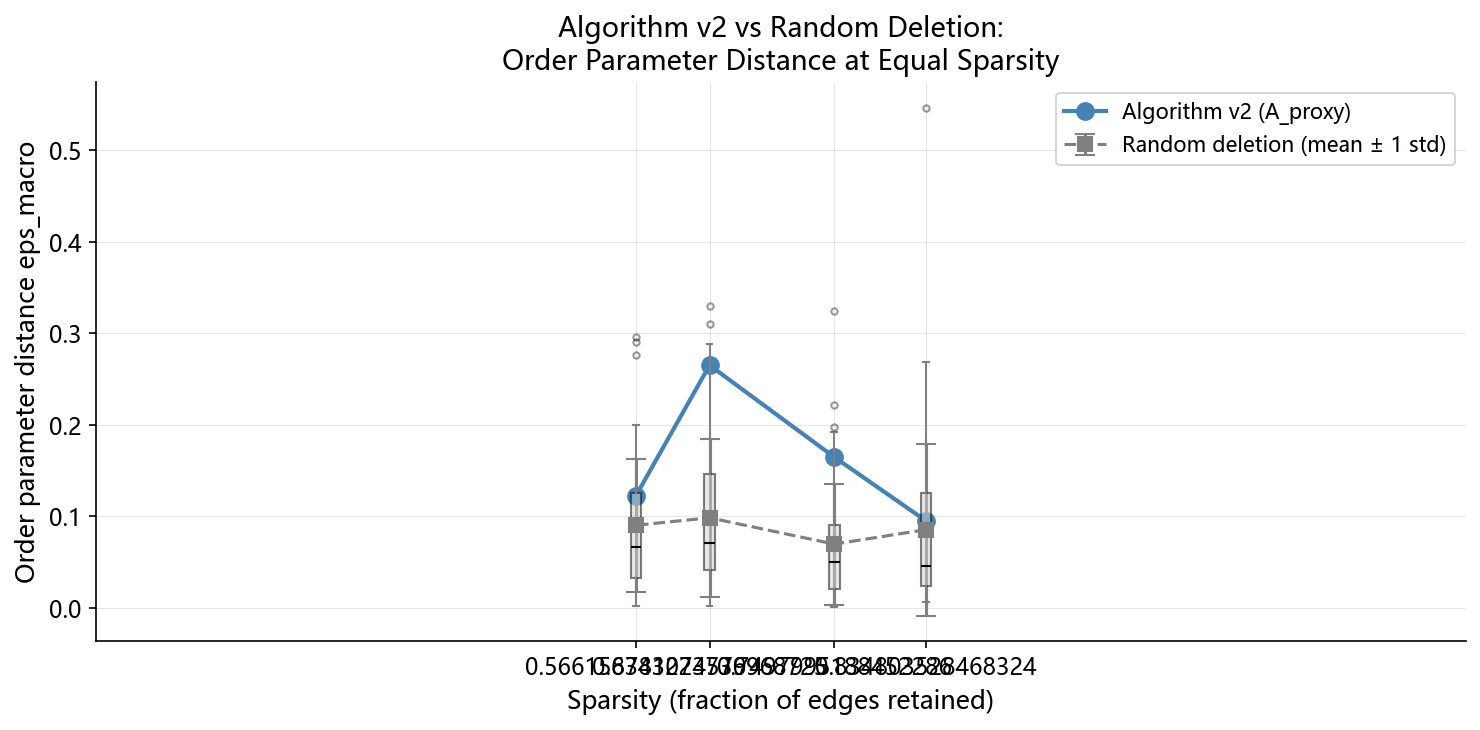

In [47]:
# ==============================================================
# 对比实验：算法稀疏化 vs 随机删边
# ==============================================================

# 1. 从 perc_records 里选几个典型 epsilon 对应的 A_proxy
#    选取原则：覆盖等价类内部（小 NRMSE）和边界附近（大 NRMSE）各一两个点
target_epsilons = [0.05, 0.10, 0.20, 0.258]   # 按你的实验结果调整

init_state = X_obs[0]
phi_true, _ = compute_order_parameter_LV(
    A_true, model, T_steady=300, init_state=init_state
)

comparison_results = []

for target_eps in target_epsilons:
    # 找最近的记录
    rec      = min(perc_records, key=lambda r: abs(r['epsilon'] - target_eps))
    A_proxy  = rec['A_sparse']
    sparsity = rec['sparsity']   # 算法达到的稀疏度，作为随机删边的目标

    # 算法稀疏化的 eps_macro
    phi_proxy, _ = compute_order_parameter_LV(
        A_proxy, model, T_steady=300, init_state=init_state
    )
    eps_macro_algo = abs(phi_proxy - phi_true) / abs(phi_true)

    # 随机删边：生成 n_samples 个相同稀疏度的网络，计算 eps_macro 分布
    rand_nets = random_sparse_network(
        A_true, target_sparsity=sparsity, n_samples=50, seed=42
    )
    eps_macro_rand = []
    for A_rand in rand_nets:
        phi_rand, _ = compute_order_parameter_LV(
            A_rand, model, T_steady=300, init_state=init_state
        )
        eps_macro_rand.append(abs(phi_rand - phi_true) / abs(phi_true))

    comparison_results.append({
        'epsilon':          rec['epsilon'],
        'sparsity':         sparsity,
        'eps_macro_algo':   eps_macro_algo,
        'eps_macro_rand':   np.array(eps_macro_rand),
        'rand_mean':        np.mean(eps_macro_rand),
        'rand_std':         np.std(eps_macro_rand),
        'rand_median':      np.median(eps_macro_rand),
    })

    print(f"eps={rec['epsilon']:.3f}  sparsity={sparsity:.3f}  "
          f"algo={eps_macro_algo:.4f}  "
          f"rand={np.mean(eps_macro_rand):.4f}±{np.std(eps_macro_rand):.4f}")

# ==============================================================
# 可视化
# ==============================================================

n_pts   = len(comparison_results)
fig, ax = plt.subplots(figsize=(10, 5))

sparsities      = [r['sparsity']       for r in comparison_results]
eps_algo        = [r['eps_macro_algo'] for r in comparison_results]
rand_means      = [r['rand_mean']      for r in comparison_results]
rand_stds       = [r['rand_std']       for r in comparison_results]

# 随机删边：均值 ± 1std 误差棒
ax.errorbar(sparsities, rand_means, yerr=rand_stds,
            fmt='s--', color='gray', lw=1.5, ms=7, capsize=5,
            label='Random deletion (mean ± 1 std)')

# 算法稀疏化：单个点
ax.plot(sparsities, eps_algo, 'o-', color='steelblue', lw=2, ms=8,
        label='Algorithm v2 (A_proxy)')

# 箱线图：展示随机删边的完整分布
for i, r in enumerate(comparison_results):
    ax.boxplot(r['eps_macro_rand'], positions=[r['sparsity']],
               widths=0.01, patch_artist=True,
               boxprops=dict(facecolor='lightgray', alpha=0.5),
               medianprops=dict(color='black'),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='.', color='gray', alpha=0.4))

ax.set_xlabel('Sparsity (fraction of edges retained)', fontsize=12)
ax.set_ylabel('Order parameter distance eps_macro', fontsize=12)
ax.set_title('Algorithm v2 vs Random Deletion:\nOrder Parameter Distance at Equal Sparsity',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Projection sparsification: 2494 -> 145 edges (sparsity 5.8%, deleted 2349)
=== sparsify_by_projection results ===
  Sparsity     : 0.058
  eps_macro    : 0.0626
  delta(A_eff) : 1.1956
  NRMSE        : 0.6180

=== Closest v2 record (eps=0.300) ===
  Sparsity     : 0.520
  eps_macro    : 0.2245
  delta(A_eff) : 0.9334
  NRMSE        : 0.2460

=== Random deletion (sparsity=0.058, n=50) ===
  eps_macro mean : 0.9343
  eps_macro std  : 0.0863
  eps_macro min  : 0.7801


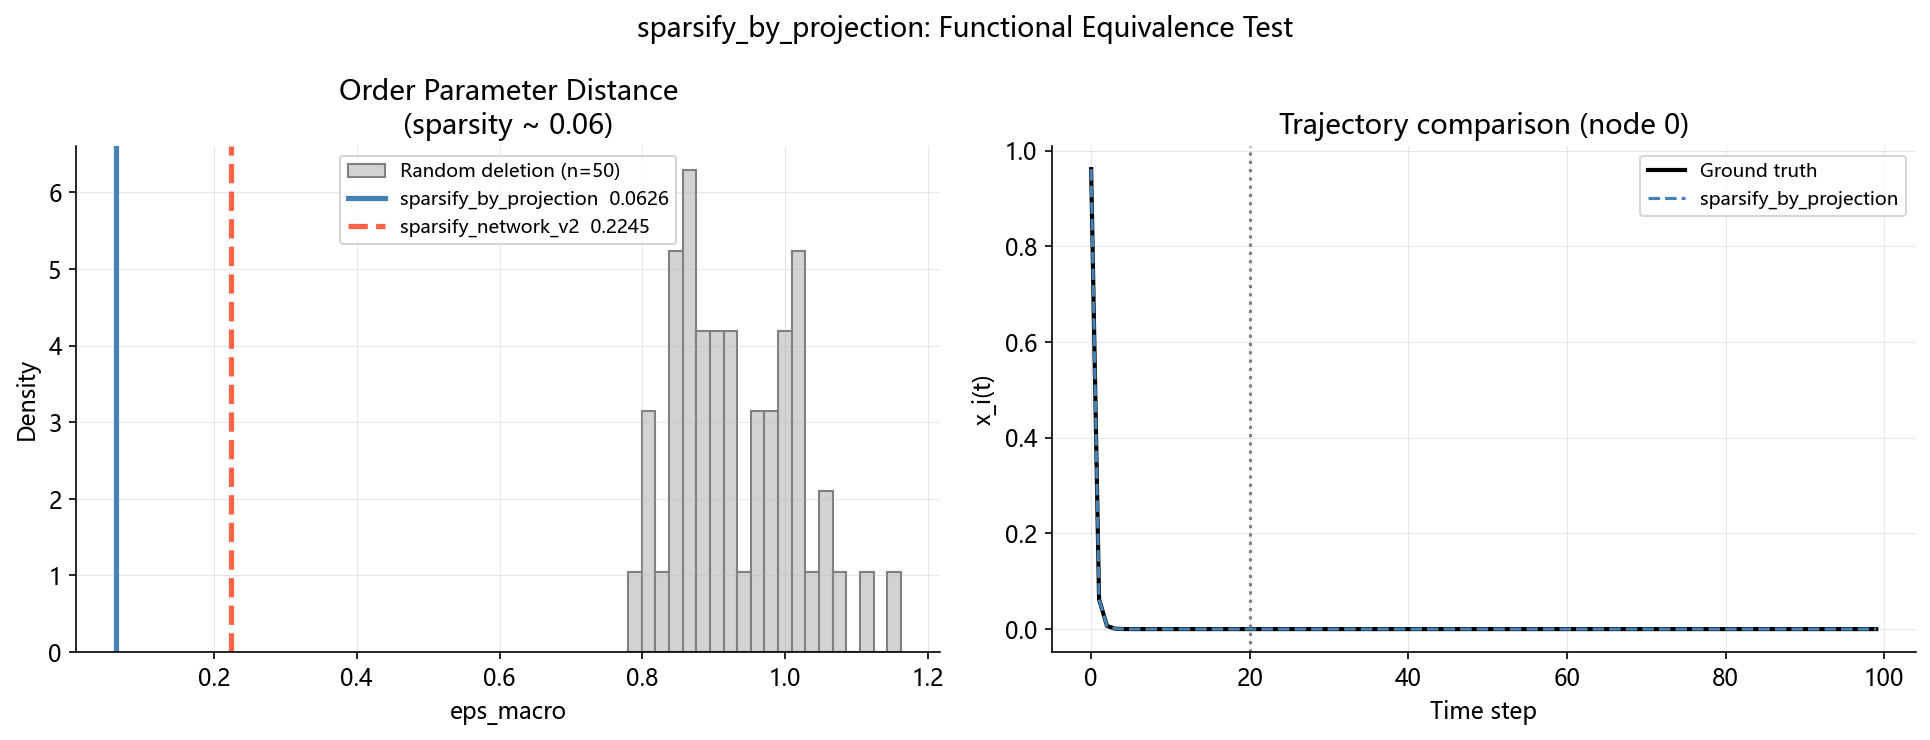

In [64]:
# ==============================================================
# 测试 sparsify_by_projection
# ==============================================================

# 1. 运行新算法（用 eps_macro 作为停止条件）
A_proj, sparsity_proj = sparsify_by_projection(
    A_true, U_dyn, model,
    eps_macro_tol=0.05,    # 容忍 5% 的序参量偏差
    T_steady=150,
    init_state=X_obs[0],
    seed=SEED
)

# 2. 计算关键指标
init_state = X_obs[0]
phi_true, _    = compute_order_parameter_LV(A_true,  model, T_steady=300, init_state=init_state)
phi_proj, _    = compute_order_parameter_LV(A_proj,  model, T_steady=300, init_state=init_state)
eps_macro_proj = abs(phi_proj - phi_true) / abs(phi_true)

# A_eff 偏差
A_eff_ref  = compute_effective_matrix(A_true, U_dyn)
A_eff_proj = compute_effective_matrix(A_proj, U_dyn)
delta_proj = (np.linalg.norm(A_eff_proj - A_eff_ref, 'fro') /
              np.linalg.norm(A_eff_ref,  'fro'))

# 预测 NRMSE
steps_pred   = len(X_obs) - T_train
X_pred_proj  = model.simulate(A_proj, T_steps=steps_pred, init_state=X_obs[T_train])
X_full_proj  = np.vstack([X_obs[:T_train], X_pred_proj])
_, nrmse_proj = evaluate_prediction_nrmse(X_obs, X_full_proj, T_train)

print("=== sparsify_by_projection results ===")
print(f"  Sparsity     : {sparsity_proj:.3f}")
print(f"  eps_macro    : {eps_macro_proj:.4f}")
print(f"  delta(A_eff) : {delta_proj:.4f}")
print(f"  NRMSE        : {nrmse_proj:.4f}")

# 3. 与 sparsify_network_v2 在相近稀疏度下对比
# 从 perc_records 找最接近 sparsity_proj 的记录
rec_v2 = min(perc_records, key=lambda r: abs(r['sparsity'] - sparsity_proj))
print(f"\n=== Closest v2 record (eps={rec_v2['epsilon']:.3f}) ===")
print(f"  Sparsity     : {rec_v2['sparsity']:.3f}")
print(f"  eps_macro    : {rec_v2['eps_macro']:.4f}")
print(f"  delta(A_eff) : {rec_v2['delta']:.4f}")
print(f"  NRMSE        : {rec_v2['nrmse']:.4f}")

# 4. 与随机删边在相同稀疏度下对比
rand_nets = random_sparse_network(
    A_true, target_sparsity=sparsity_proj, n_samples=50, seed=SEED
)
eps_macro_rand = []
for A_rand in rand_nets:
    phi_r, _ = compute_order_parameter_LV(
        A_rand, model, T_steady=150, init_state=init_state
    )
    eps_macro_rand.append(abs(phi_r - phi_true) / abs(phi_true))

print(f"\n=== Random deletion (sparsity={sparsity_proj:.3f}, n=50) ===")
print(f"  eps_macro mean : {np.mean(eps_macro_rand):.4f}")
print(f"  eps_macro std  : {np.std(eps_macro_rand):.4f}")
print(f"  eps_macro min  : {np.min(eps_macro_rand):.4f}")

# 5. 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：eps_macro 对比（算法 vs 随机分布）
ax = axes[0]
ax.hist(eps_macro_rand, bins=20, color='lightgray', edgecolor='gray',
        density=True, label=f'Random deletion (n=50)')
ax.axvline(eps_macro_proj, color='steelblue', lw=2.5,
           label=f'sparsify_by_projection  {eps_macro_proj:.4f}')
ax.axvline(rec_v2['eps_macro'], color='tomato', lw=2.5, ls='--',
           label=f'sparsify_network_v2  {rec_v2["eps_macro"]:.4f}')
ax.set_xlabel('eps_macro')
ax.set_ylabel('Density')
ax.set_title(f'Order Parameter Distance\n(sparsity ~ {sparsity_proj:.2f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 右：轨迹对比
ax = axes[1]
t_ax   = np.arange(len(X_obs))
node   = 0    # 选一个代表节点
ax.plot(t_ax, X_obs[:, node],       color='black',    lw=2,   label='Ground truth')
ax.plot(t_ax, X_full_proj[:, node], color='steelblue', lw=1.5, ls='--',
        label='sparsify_by_projection')
ax.axvline(T_train, color='gray', ls=':', lw=1.5)
ax.set_xlabel('Time step')
ax.set_ylabel('x_i(t)')
ax.set_title(f'Trajectory comparison (node {node})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('sparsify_by_projection: Functional Equivalence Test', fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
def sparsify_by_projection_v2(A_true, U_dyn, model, X_obs, T_train_steps,
                               eps_macro_tol=0.05, nrmse_tol=0.10,
                               T_steady=150, init_state=None, seed=42):
    """
    Greedy edge deletion with dual stopping criterion:
      1. eps_macro < eps_macro_tol  (steady-state functional equivalence)
      2. NRMSE     < nrmse_tol      (trajectory prediction accuracy)
    An edge is deleted only if BOTH conditions are satisfied after deletion.
    """
    if init_state is None:
        np.random.seed(seed)
        init_state = np.random.rand(model.N)

    rho_true   = float(np.max(np.abs(np.linalg.eigvals(A_true))))
    P          = U_dyn @ U_dyn.T
    col_norms  = np.linalg.norm(P, axis=0)
    row_norms  = np.linalg.norm(P, axis=1)

    steps_pred = len(X_obs) - T_train_steps
    X_train    = X_obs[:T_train_steps]

    # Reference quantities
    phi_true, _ = compute_order_parameter_LV(
        A_true, model, T_steady=T_steady, init_state=init_state
    )

    # Sort edges by projection norm ascending (weakest A_eff contribution first)
    edges        = list(zip(*np.where(np.abs(A_true) > 1e-9)))
    edges_sorted = sorted(edges,
                          key=lambda e: row_norms[e[0]] * col_norms[e[1]])

    A_current = A_true.copy()
    n_deleted = 0
    n_rejected_macro = 0
    n_rejected_nrmse = 0

    print(f"Dual-criterion sparsification: "
          f"eps_macro_tol={eps_macro_tol}, nrmse_tol={nrmse_tol}")
    print(f"Total edges to attempt: {len(edges_sorted)}")

    for (i, j) in edges_sorted:
        A_tmp      = A_current.copy()
        A_tmp[i, j] = 0.0

        rho_tmp = float(np.max(np.abs(np.linalg.eigvals(A_tmp))))
        if rho_tmp < 1e-9:
            break
        A_tmp_norm = A_tmp * (rho_true / rho_tmp)

        # Check eps_macro
        phi_tmp, _ = compute_order_parameter_LV(
            A_tmp_norm, model, T_steady=T_steady, init_state=init_state
        )
        eps_macro = abs(phi_tmp - phi_true) / max(abs(phi_true), 1e-9)
        if eps_macro >= eps_macro_tol:
            n_rejected_macro += 1
            continue

        # Check NRMSE
        try:
            X_pred = model.simulate(
                A_tmp_norm, T_steps=steps_pred,
                init_state=X_obs[T_train_steps]
            )
            X_full = np.vstack([X_train, X_pred])
            _, nrmse = evaluate_prediction_nrmse(X_obs, X_full, T_train_steps)
        except Exception:
            n_rejected_nrmse += 1
            continue

        if nrmse >= nrmse_tol:
            n_rejected_nrmse += 1
            continue

        # Both criteria satisfied: accept deletion
        A_current = A_tmp_norm
        n_deleted += 1

    n_orig   = len(edges)
    n_final  = int(np.sum(np.abs(A_current) > 1e-9))
    sparsity = n_final / max(n_orig, 1)

    print(f"Done: {n_orig} -> {n_final} edges (sparsity {sparsity:.1%})")
    print(f"  Deleted: {n_deleted}  "
          f"Rejected by eps_macro: {n_rejected_macro}  "
          f"Rejected by NRMSE: {n_rejected_nrmse}")
    return A_current, sparsity

In [66]:
A_proj2, sparsity2 = sparsify_by_projection_v2(
    A_true, U_dyn, model, X_obs,
    T_train_steps=T_train,
    eps_macro_tol=0.05,
    nrmse_tol=0.10,        # 容忍 10% 的轨迹误差
    T_steady=150,
    init_state=X_obs[0],
    seed=SEED
)

Dual-criterion sparsification: eps_macro_tol=0.05, nrmse_tol=0.1
Total edges to attempt: 2494
Done: 2494 -> 448 edges (sparsity 18.0%)
  Deleted: 2046  Rejected by eps_macro: 158  Rejected by NRMSE: 290


In [68]:
# 验证最终结果
phi_final, _ = compute_order_parameter_LV(
    A_proj2, model, T_steady=300, init_state=X_obs[0]
)
eps_macro_final = abs(phi_final - phi_true) / abs(phi_true)

X_pred_final = model.simulate(
    A_proj2, T_steps=steps_pred, init_state=X_obs[T_train]
)
X_full_final = np.vstack([X_obs[:T_train], X_pred_final])
_, nrmse_final = evaluate_prediction_nrmse(X_obs, X_full_final, T_train)

print(f"Final verification:")
print(f"  eps_macro : {eps_macro_final:.4f}  (tol={0.05})")
print(f"  NRMSE     : {nrmse_final:.4f}  (tol={0.10})")

Final verification:
  eps_macro : 0.0655  (tol=0.05)
  NRMSE     : 0.0998  (tol=0.1)


In [72]:
def plot_trajectory_overlay(A_proxy, A_true, model, X_obs,
                            T_train_steps, num_nodes=10,
                            scatter_interval=2, seed=42,
                            title=None, save_path=None):
    np.random.seed(seed)
    T, N      = X_obs.shape
    n_plot    = min(num_nodes, N)
    nodes     = np.linspace(0, N - 1, n_plot, dtype=int)
    colors    = [plt.cm.tab10(i % 10) for i in range(n_plot)]
    t_ax      = np.arange(T)

    init_state = X_obs[0]
    X_proxy    = model.simulate(A_proxy, T_steps=T, init_state=init_state)
    nrmse      = compute_nrmse(X_obs, X_proxy)

    fig, ax = plt.subplots(figsize=(12, 5))
    sp = np.arange(0, T, scatter_interval)

    for idx, node in enumerate(nodes):
        c = colors[idx]
        ax.plot(t_ax, X_obs[:, node],
                color=c, lw=1.8, alpha=0.75)
        ax.scatter(t_ax[sp], X_proxy[sp, node],
                   edgecolors=c, facecolors='none',
                   marker='o', s=25, lw=1.2, alpha=0.85)

    ax.axvline(T_train_steps, color='gray', ls=':', lw=1.5, alpha=0.8)
    ax.legend([
        Line2D([0], [0], color='gray', lw=2),
        Line2D([0], [0], color='gray', marker='o', ls='None',
               markerfacecolor='none', markeredgewidth=1.2, markersize=6)
    ], ['Ground truth (A_true)', 'A_proxy simulation'],
       loc='upper right', fontsize=10)

    ax.set_xlabel('Time step', fontsize=12)
    ax.set_ylabel('x_i(t)', fontsize=12)
    ax.set_title(
        title or ('Trajectory overlay: A_true vs A_proxy\n'
                  f'NRMSE = {nrmse:.4f},  {n_plot} of {N} nodes shown'),
        fontsize=13
    )
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()
    return X_proxy, nrmse

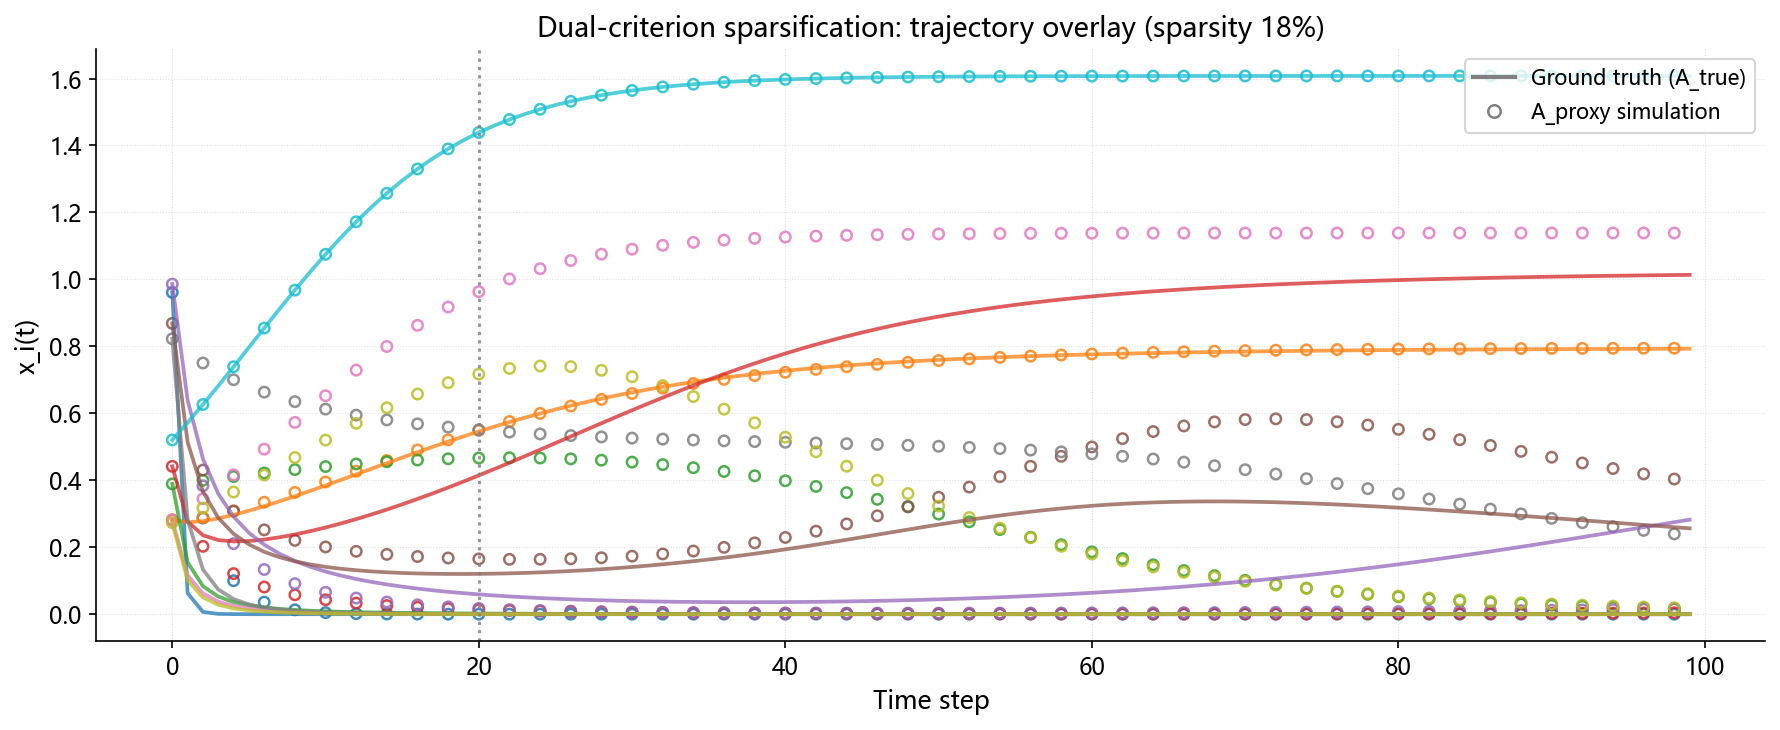

In [74]:
X_proxy_sim, nrmse_val = plot_trajectory_overlay(
    A_proj2, A_true, model, X_obs,
    T_train_steps=T_train,
    num_nodes=10,
    scatter_interval=2,
    title='Dual-criterion sparsification: trajectory overlay (sparsity 18%)'
)

NRMSE (t>=20, A_proj2 from true init): 0.0998


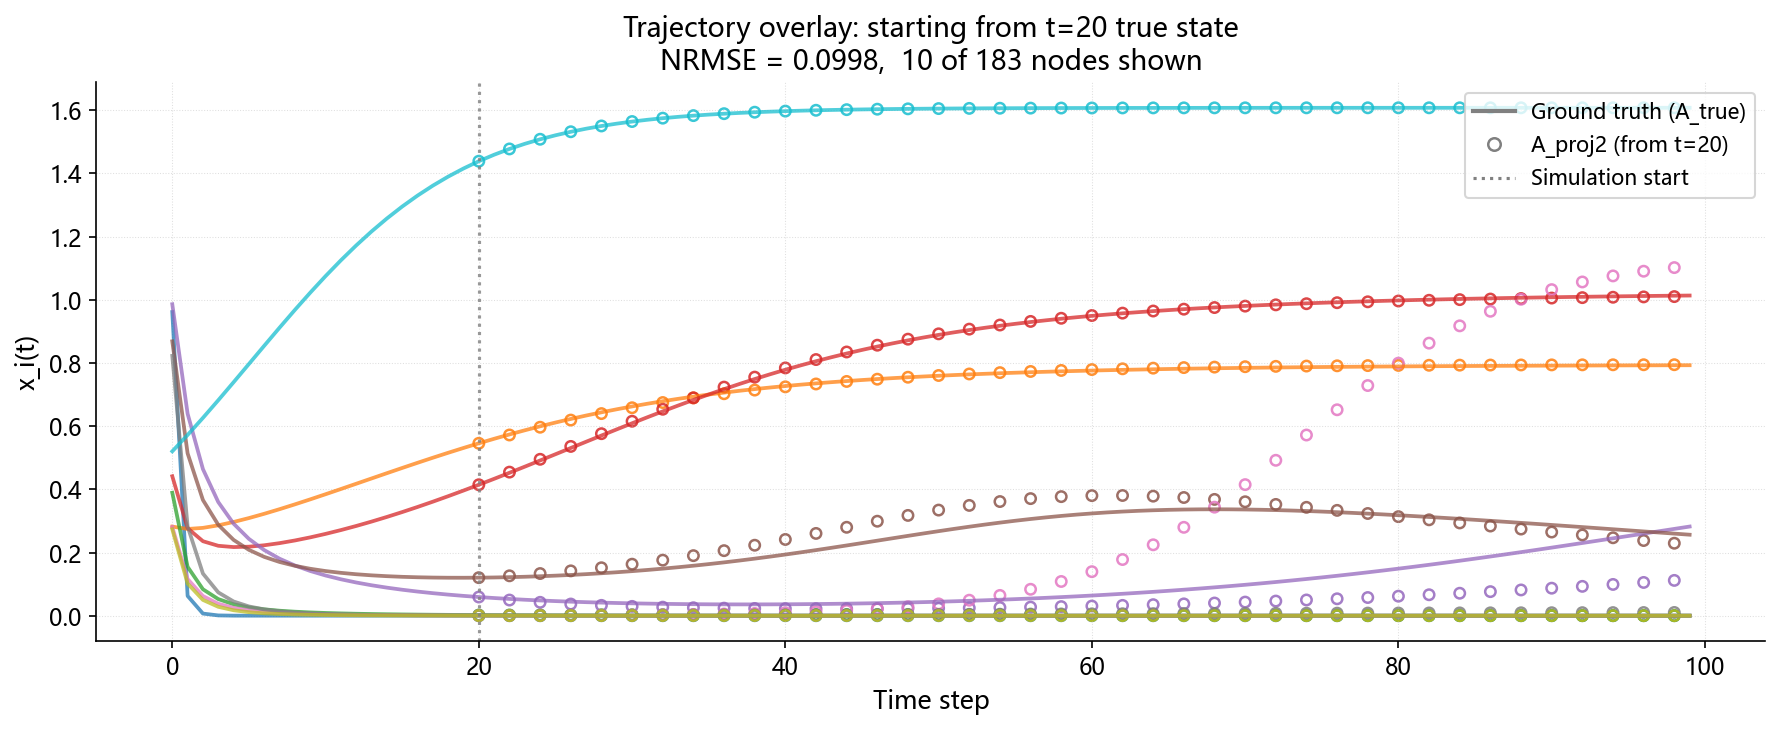

In [75]:
# 从 t=20 的真实状态出发，在 A_proj2 上运行动力学
init_t20   = X_obs[T_train]           # 真实轨迹 t=20 的状态作为初始条件
steps_from_t20 = len(X_obs) - T_train # 剩余步数

X_from_t20 = model.simulate(A_proj2, T_steps=steps_from_t20, init_state=init_t20)

# 计算这段区间的 NRMSE
nrmse_t20 = compute_nrmse(X_obs[T_train:], X_from_t20)
print(f"NRMSE (t>=20, A_proj2 from true init): {nrmse_t20:.4f}")

# 画图：只画 t=20 之后的部分
T, N      = X_obs.shape
n_plot    = min(10, N)
nodes     = np.linspace(0, N - 1, n_plot, dtype=int)
colors    = [plt.cm.tab10(i % 10) for i in range(n_plot)]
t_full    = np.arange(T)                       # 全段时间轴（用于真实轨迹）
t_pred    = np.arange(T_train, T)              # t>=20 的时间轴（用于预测轨迹）
sp        = np.arange(0, steps_from_t20, 2)   # scatter 间隔

fig, ax = plt.subplots(figsize=(12, 5))

for idx, node in enumerate(nodes):
    c = colors[idx]
    # 真实轨迹：全段实线（含 t<20 部分作为上下文）
    ax.plot(t_full, X_obs[:, node],
            color=c, lw=1.8, alpha=0.75)
    # A_proj2 模拟：t>=20 的散点
    ax.scatter(t_pred[sp], X_from_t20[sp, node],
               edgecolors=c, facecolors='none',
               marker='o', s=25, lw=1.2, alpha=0.85)

ax.axvline(T_train, color='gray', ls=':', lw=1.5, alpha=0.8,
           label=f't = {T_train} (simulation start)')
ax.legend([
    Line2D([0], [0], color='gray', lw=2),
    Line2D([0], [0], color='gray', marker='o', ls='None',
           markerfacecolor='none', markeredgewidth=1.2, markersize=6),
    Line2D([0], [0], color='gray', ls=':', lw=1.5)
], ['Ground truth (A_true)', 'A_proj2 (from t=20)', 'Simulation start'],
   loc='upper right', fontsize=10)

ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('x_i(t)', fontsize=12)
ax.set_title(
    f'Trajectory overlay: starting from t={T_train} true state\n'
    f'NRMSE = {nrmse_t20:.4f},  {n_plot} of {N} nodes shown',
    fontsize=13
)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

NRMSE (t>=10, A_proj2 from true init): 0.1757


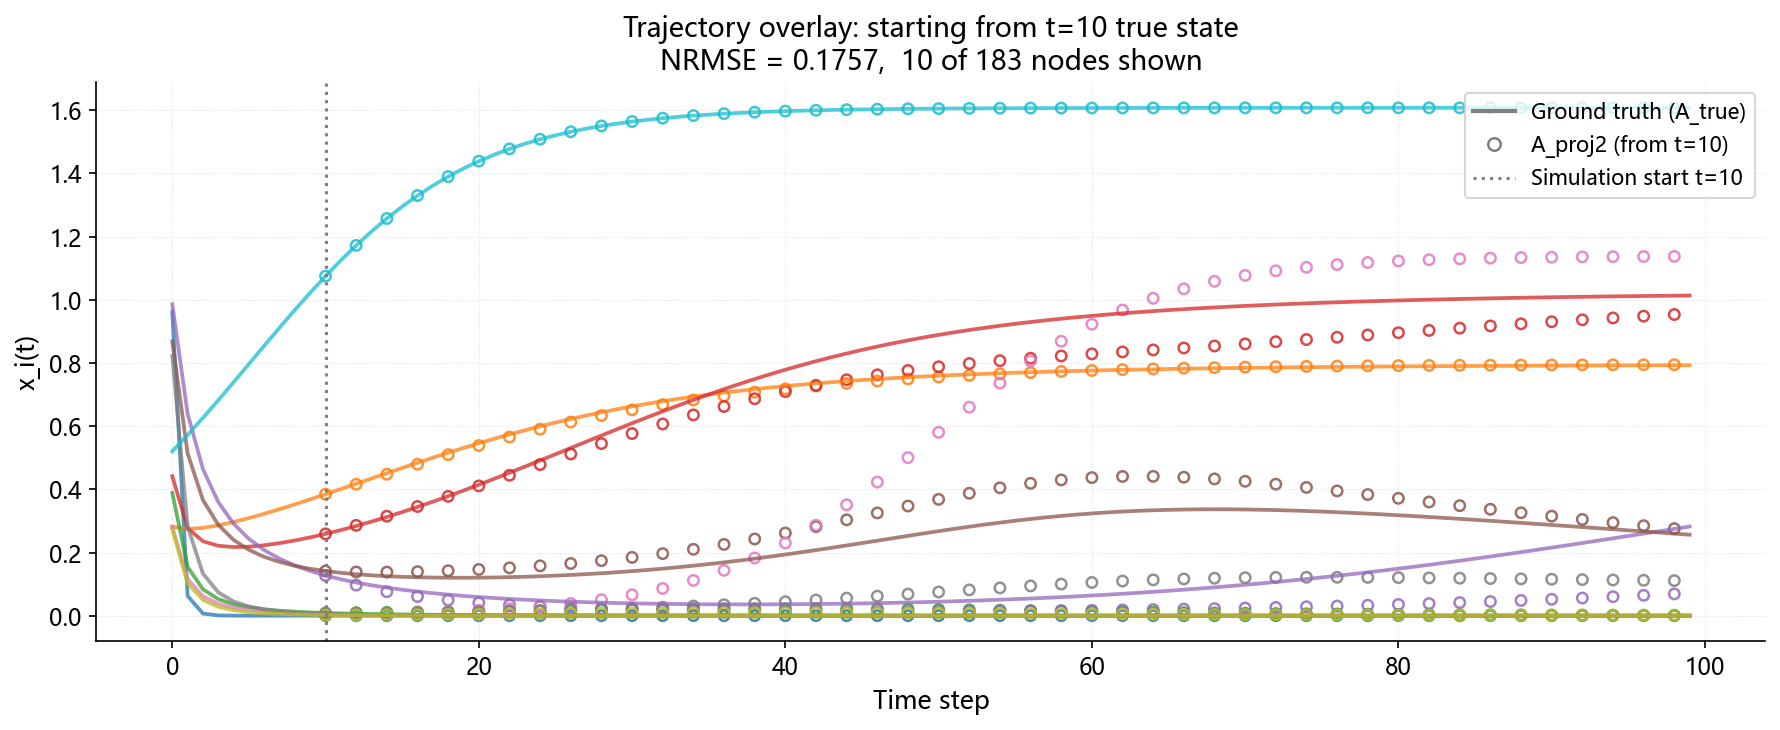

In [77]:
# 从 t=10 的真实状态出发，在 A_proj2 上运行动力学
T_start    = 10
init_t10   = X_obs[T_start]
steps_from_t10 = len(X_obs) - T_start

X_from_t10 = model.simulate(A_proj2, T_steps=steps_from_t10, init_state=init_t10)

nrmse_t10 = compute_nrmse(X_obs[T_start:], X_from_t10)
print(f"NRMSE (t>={T_start}, A_proj2 from true init): {nrmse_t10:.4f}")

# 画图
n_plot  = min(10, N)
nodes   = np.linspace(0, N - 1, n_plot, dtype=int)
colors  = [plt.cm.tab10(i % 10) for i in range(n_plot)]
t_full  = np.arange(T)
t_pred  = np.arange(T_start, T)
sp      = np.arange(0, steps_from_t10, 2)

fig, ax = plt.subplots(figsize=(12, 5))

for idx, node in enumerate(nodes):
    c = colors[idx]
    ax.plot(t_full, X_obs[:, node], color=c, lw=1.8, alpha=0.75)
    ax.scatter(t_pred[sp], X_from_t10[sp, node],
               edgecolors=c, facecolors='none',
               marker='o', s=25, lw=1.2, alpha=0.85)

ax.axvline(T_start, color='gray', ls=':', lw=1.5)
ax.legend([
    Line2D([0], [0], color='gray', lw=2),
    Line2D([0], [0], color='gray', marker='o', ls='None',
           markerfacecolor='none', markeredgewidth=1.2, markersize=6),
    Line2D([0], [0], color='gray', ls=':', lw=1.5)
], ['Ground truth (A_true)', f'A_proj2 (from t={T_start})',
    f'Simulation start t={T_start}'],
   loc='upper right', fontsize=10)

ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('x_i(t)', fontsize=12)
ax.set_title(
    f'Trajectory overlay: starting from t={T_start} true state\n'
    f'NRMSE = {nrmse_t10:.4f},  {n_plot} of {N} nodes shown',
    fontsize=13
)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [78]:
# 汇总不同起点的 NRMSE
for t_s in [0, 5, 10, 15, 20]:
    X_sim = model.simulate(A_proj2, T_steps=len(X_obs)-t_s,
                            init_state=X_obs[t_s])
    print(f"t_start={t_s:>3d}  NRMSE={compute_nrmse(X_obs[t_s:], X_sim):.4f}")

t_start=  0  NRMSE=0.5688
t_start=  5  NRMSE=0.2606
t_start= 10  NRMSE=0.1757
t_start= 15  NRMSE=0.1317
t_start= 20  NRMSE=0.0998


transverse comparing experiments: same LV dynamics in different network ensembles (from groundtruth to ER, SBM, BA)

In [ ]:
# 固定分布范围，每个网络独立采样
def make_model_for_network(A_net, seed=42):
    N = A_net.shape[0]
    rng = np.random.default_rng(seed)
    alpha_i = rng.uniform(0.5, 1.5, N)
    theta_i = rng.uniform(0.5, 1.5, N)
    x0_i    = rng.uniform(0.0, 1.0, N)
    model_i = LVDynamics(N, alpha=alpha_i, theta=theta_i, dt=0.1)
    return model_i, x0_i

In [94]:
# ==============================================================
# 横向实验：ER / BA / SBM 系综，每种 n_instances 个实例
# ==============================================================

n_instances = 10   # 每种网络测几个实例，先用 10，结果稳定后可加到 20-50

ensemble_configs = [
    ('ER',  42),
    # ('BA',  142),
    # ('SBM', 242),
]

all_ensemble_records = {}   # {'ER': [records_0, records_1, ...], ...}

for net_type, base_seed in ensemble_configs:
    print(f"\n{'='*55}")
    print(f"Ensemble: {net_type}  ({n_instances} instances)")
    print(f"{'='*55}")

    records_list = []

    for i in range(n_instances):
        seed_i = base_seed + i

        # Step 1: 生成网络
        A_i = generate_reference_network(A_true, net_type, seed=seed_i)

        # Step 2: 生成动力学参数和初始条件
        model_i, x0_i = make_model_for_network(A_i, seed=seed_i)

        # Step 3: 模拟 ground truth 轨迹
        X_obs_i = model_i.simulate(
            A_i, T_steps=T_total, init_state=x0_i, seed=seed_i
        )

        # Step 4: 提取动力学子空间
        U_dyn_i = extract_dynamical_basis(
            X_obs_i, energy_threshold=0.98, min_k=N
        )

        # Step 5: 跑 percolation 扫描
        records_i = scan_epsilon_percolation(
            A_i, U_dyn_i, model_i, X_obs_i,
            T_train_steps=T_train,
            epsilon_range=np.sort(epsilon_range),
            T_sim=500, T_steady=150,
            seed=seed_i, verbose=False
        )
        records_list.append(records_i)
        print(f"  [{net_type}] instance {i+1:>2d}/{n_instances} done")

    all_ensemble_records[net_type] = records_list
    print(f"  {net_type} ensemble complete.")


Ensemble: ER  (10 instances)
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2440, avg degree=13.33
  [ER] instance  1/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2397, avg degree=13.10
  [ER] instance  2/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2493, avg degree=13.62
  [ER] instance  3/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2463, avg degree=13.46
  [ER] instance  4/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2490, avg degree=13.61
  [ER] instance  5/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2491, avg degree=13.61
  [ER] instance  6/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2439, avg degree=13.33
  [ER] instance  7/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2536, avg degree=13.86
  [ER] instance  8/10 done
Reference: N=183, edges=2494, avg 

In [95]:
for net_type, records_list in all_ensemble_records.items():
    for i, records in enumerate(records_list):
        k = records[0].get('k', '未记录')
        nrmse_min = min(r['nrmse'] for r in records)
        print(f"{net_type} instance {i+1}: k={k}, "
              f"min NRMSE={nrmse_min:.4f}")

ER instance 1: k=未记录, min NRMSE=0.0100
ER instance 2: k=未记录, min NRMSE=0.0108
ER instance 3: k=未记录, min NRMSE=0.0605
ER instance 4: k=未记录, min NRMSE=0.0074
ER instance 5: k=未记录, min NRMSE=0.0142
ER instance 6: k=未记录, min NRMSE=0.0119
ER instance 7: k=未记录, min NRMSE=0.0482
ER instance 8: k=未记录, min NRMSE=0.0145
ER instance 9: k=未记录, min NRMSE=0.0200
ER instance 10: k=未记录, min NRMSE=0.0083


In [96]:
'''
diagnose
'''
for i in range(n_instances):
    seed_i = base_seed + i
    A_i = generate_reference_network(A_true, net_type, seed=seed_i)
    model_i, x0_i = make_model_for_network(A_i, seed=seed_i)
    X_obs_i = model_i.simulate(A_i, T_steps=T_total, 
                                init_state=x0_i, seed=seed_i)
    U_dyn_i = extract_dynamical_basis(X_obs_i, 
                                       energy_threshold=0.98, min_k=N)
    
    # ── 诊断信息 ──
    phi_i, _ = compute_order_parameter_LV(
        A_i, model_i, T_steady=150, init_state=x0_i)
    A_eff_i = U_dyn_i.T @ A_i @ U_dyn_i
    print(f"  instance {i+1}: k={U_dyn_i.shape[1]}, "
          f"Phi={phi_i:.3f}, "
          f"||A_eff||={np.linalg.norm(A_eff_i,'fro'):.3f}, "
          f"edges={np.sum(np.abs(A_i)>1e-9)}")

Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2440, avg degree=13.33
  instance 1: k=100, Phi=0.132, ||A_eff||=28.923, edges=2440
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2397, avg degree=13.10
  instance 2: k=100, Phi=0.167, ||A_eff||=29.074, edges=2397
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2493, avg degree=13.62
  instance 3: k=100, Phi=0.141, ||A_eff||=29.833, edges=2493
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2463, avg degree=13.46
  instance 4: k=100, Phi=0.151, ||A_eff||=29.833, edges=2463
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2490, avg degree=13.61
  instance 5: k=100, Phi=0.120, ||A_eff||=29.794, edges=2490
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2491, avg degree=13.61
  instance 6: k=100, Phi=0.132, ||A_eff||=30.043, edges=2491
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2439, avg degree=13.33
  in

In [92]:
def plot_ensemble_percolation(records_list, net_type,
                               nrmse_weak=0.15, save_path=None):
    """
    Plot ensemble-averaged NRMSE and eps_macro vs epsilon,
    with shaded ±1 std bands across instances.
    """
    # 取公共 epsilon 网格（所有实例共用同一 epsilon_range，直接叠加）
    eps_ref = np.array([r['epsilon'] for r in records_list[0]
                        if np.isfinite(r['nrmse'])])

    nrmse_mat  = []   # (n_instances, n_eps)
    macro_mat  = []

    for records in records_list:
        valid = [r for r in records if np.isfinite(r['nrmse'])]
        nrmse_mat.append([r['nrmse']     for r in valid])
        macro_mat.append([r['eps_macro'] for r in valid])

    nrmse_mat = np.array(nrmse_mat)   # (n_instances, n_eps)
    macro_mat = np.array(macro_mat)

    nrmse_mean, nrmse_std = nrmse_mat.mean(0), nrmse_mat.std(0)
    macro_mean, macro_std = macro_mat.mean(0), macro_mat.std(0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, mean, std, ylabel, color in zip(
        axes,
        [nrmse_mean, macro_mean],
        [nrmse_std,  macro_std],
        ['NRMSE', 'Order parameter distance (eps_macro)'],
        ['tomato', 'steelblue']
    ):
        ax.plot(eps_ref, mean, 'o-', color=color, lw=2, ms=4,
                label='Ensemble mean')
        ax.fill_between(eps_ref, mean - std, mean + std,
                        color=color, alpha=0.2, label='±1 std')

        # Individual instance curves (light, for reference)
        data_mat = nrmse_mat if ylabel == 'NRMSE' else macro_mat
        for row in data_mat:
            ax.plot(eps_ref, row, color=color, lw=0.6, alpha=0.25)

        ax.axhline(nrmse_weak, color='gray', ls='--', lw=1.2, alpha=0.7,
                   label=f'Weak equiv. {nrmse_weak}')
        ax.set_xlabel('Tolerance epsilon', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'{net_type} ensemble  (n={len(records_list)} instances)\n'
        f'LV dynamics — equivalence class boundary scan',
        fontsize=13
    )
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close(fig)
    else:
        plt.show()

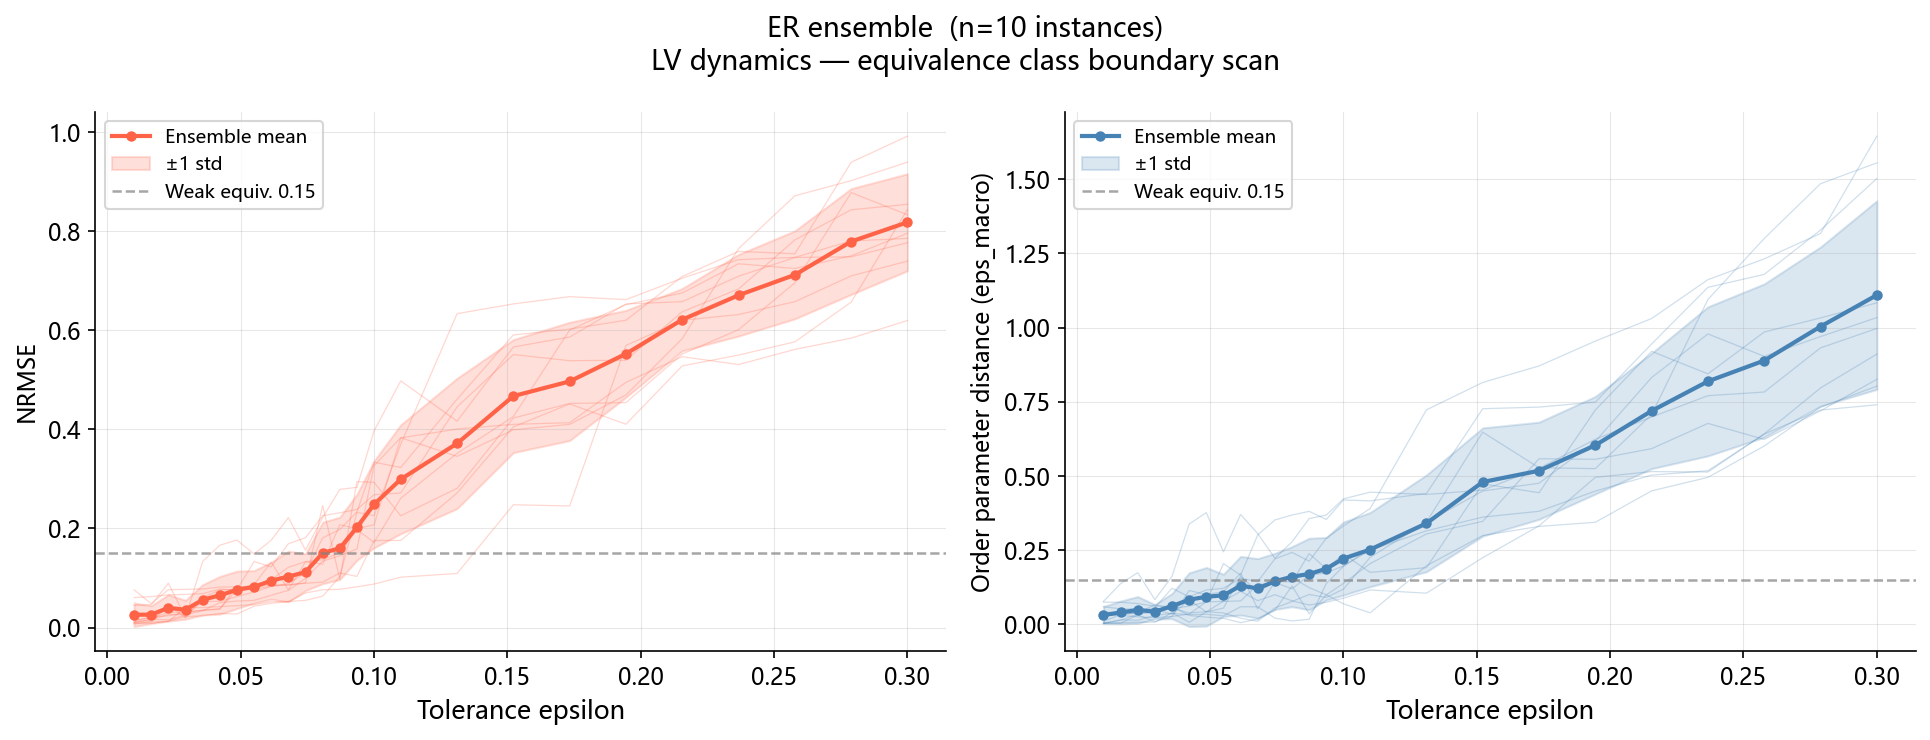

In [97]:
# 对三种网络各出一张图
for net_type, records_list in all_ensemble_records.items():
    plot_ensemble_percolation(
        records_list, net_type,
        nrmse_weak=0.15,
        save_path=None   # 改为 f'figures/{net_type}_ensemble.pdf' 则保存
    )

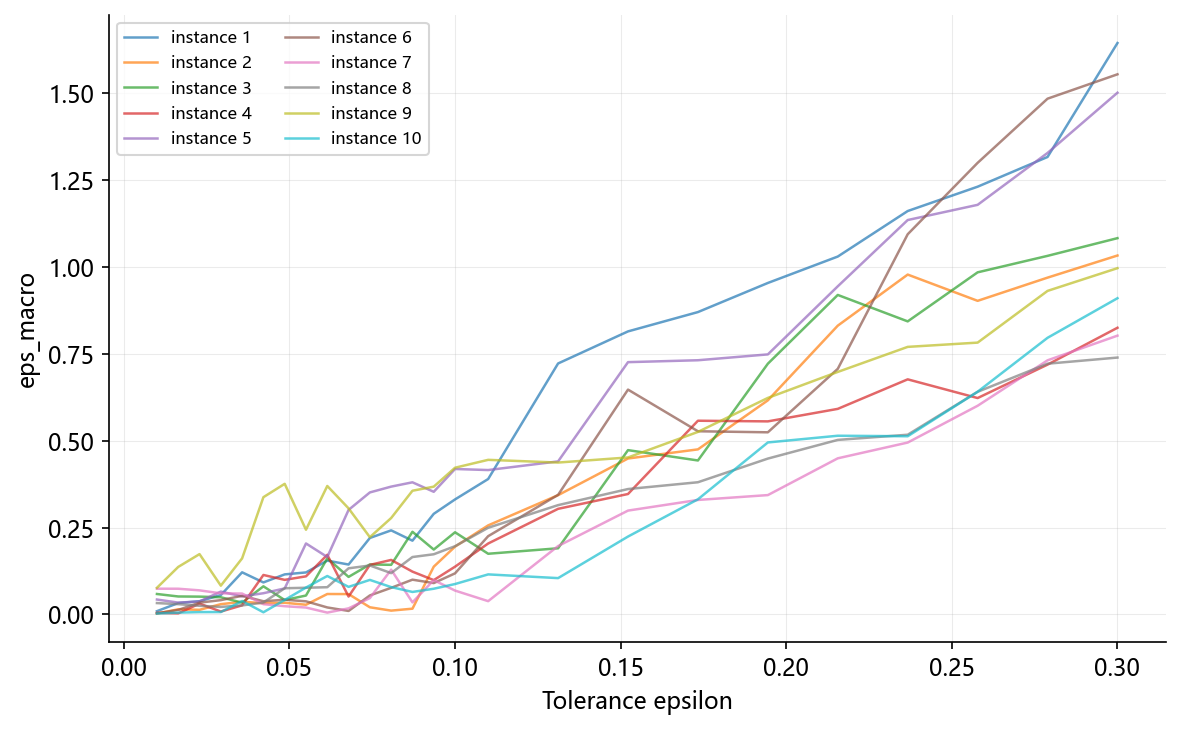

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, records in enumerate(all_ensemble_records['ER']):
    eps_vals  = [r['epsilon']  for r in records]
    emac_vals = [r['eps_macro'] for r in records]
    ax.plot(eps_vals, emac_vals, alpha=0.7, lw=1.2, 
            label=f'instance {i+1}')
ax.set_xlabel('Tolerance epsilon')
ax.set_ylabel('eps_macro')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

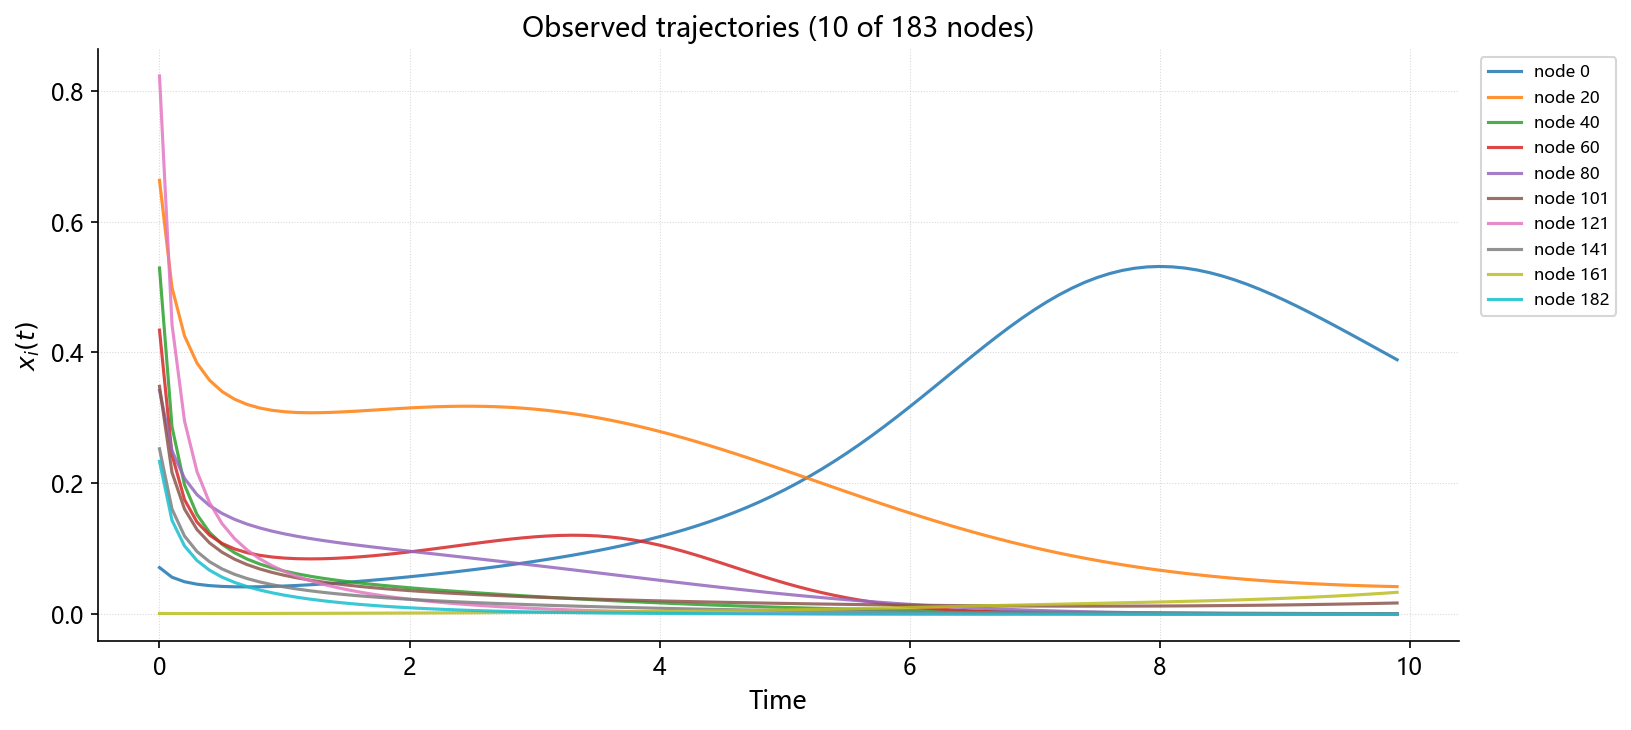

In [99]:
plot_trajectory(X_obs_i, num_nodes=10, t_end=100)

In [105]:
def check_steady_state_quality(A_list, model_list, init_state_list,
                                T_short=150, T_long=500,
                                tol_node=0.05, tol_phi=0.05):
    """
    对比 T_steady=150 和 T_steady=500 的稳态质量。
    
    参数
    ----
    A_list         : list of np.ndarray  每个实例的网络矩阵
    model_list     : list of model       每个实例的动力学模型
    init_state_list: list of np.ndarray  每个实例的初始条件
    T_short        : int                 短模拟步数（当前设定值）
    T_long         : int                 长模拟步数（参考值）
    tol_node       : float               节点级别收敛容忍度
    tol_phi        : float               序参量相对误差容忍度
    
    返回
    ----
    results : list of dict
    """
    results = []
    print(f"{'inst':>5}  {'Phi(short)':>10}  {'Phi(long)':>9}  "
          f"{'Phi_err':>8}  {'unconverged':>12}  {'status':>6}")
    print("─" * 60)
    
    for i, (A_i, model_i, x0_i) in enumerate(
        zip(A_list, model_list, init_state_list)
    ):
        X_short = model_i.simulate(A_i, T_steps=T_short, init_state=x0_i)
        X_long  = model_i.simulate(A_i, T_steps=T_long,  init_state=x0_i)
        
        # 取最后 20% 作为稳态窗口
        x_inf_short = X_short[int(0.8 * T_short):].mean(axis=0)
        x_inf_long  = X_long[int(0.8  * T_long):].mean(axis=0)
        
        phi_short = float(np.mean(x_inf_short))
        phi_long  = float(np.mean(x_inf_long))
        phi_err   = abs(phi_short - phi_long) / max(abs(phi_long), 1e-9)
        
        node_err      = np.abs(x_inf_short - x_inf_long)
        n_unconverged = int(np.sum(node_err > tol_node))
        n_total       = len(x_inf_short)
        
        ok = (phi_err < tol_phi) and (n_unconverged / n_total < 0.10)
        status = '✓' if ok else '✗'
        
        print(f"{i+1:>5}  {phi_short:>10.4f}  {phi_long:>9.4f}  "
              f"{phi_err:>8.4f}  {n_unconverged:>5}/{n_total:<5}  {status:>6}")
        
        results.append({
            'instance': i + 1,
            'phi_short': phi_short,
            'phi_long':  phi_long,
            'phi_err':   phi_err,
            'n_unconverged': n_unconverged,
            'n_total':   n_total,
            'ok':        ok,
        })
    
    n_ok = sum(r['ok'] for r in results)
    print(f"─" * 60)
    print(f"通过: {n_ok}/{len(results)}  "
          f"(Phi_err < {tol_phi}, 未收敛节点 < 10%)")
    return results

In [106]:
BA_A_list     = []
BA_model_list = []
BA_x0_list    = []

for i in range(n_instances):
    seed_i  = 142 + i
    A_i     = generate_reference_network(A_true, 'BA', seed=seed_i)
    model_i, x0_i = make_model_for_network(A_i, seed=seed_i)
    BA_A_list.append(A_i)
    BA_model_list.append(model_i)
    BA_x0_list.append(x0_i)

# 稳态质量检验
ss_results = check_steady_state_quality(
    BA_A_list, BA_model_list, BA_x0_list,
    T_short=150, T_long=500
)

Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
Reference: N=183, edges=2494, avg degree=13.63
Generated BA: edges=2464, avg degree=13.46
 inst  Phi(short)  Phi(long)   Phi_err   unconverged  status
───────────────────────────────────────

In [94]:
# ==============================================================
# 横向实验：ER / BA / SBM 系综，每种 n_instances 个实例
# ==============================================================

n_instances = 10   # 每种网络测几个实例，先用 10，结果稳定后可加到 20-50

ensemble_configs = [
    # ('ER',  42),
    ('BA',  142),
    # ('SBM', 242),
]

all_ensemble_records = {}   # {'ER': [records_0, records_1, ...], ...}

for net_type, base_seed in ensemble_configs:
    print(f"\n{'='*55}")
    print(f"Ensemble: {net_type}  ({n_instances} instances)")
    print(f"{'='*55}")

    records_list = []

    for i in range(n_instances):
        seed_i = base_seed + i

        # Step 1: 生成网络
        A_i = generate_reference_network(A_true, net_type, seed=seed_i)

        # Step 2: 生成动力学参数和初始条件
        model_i, x0_i = make_model_for_network(A_i, seed=seed_i)

        # Step 3: 模拟 ground truth 轨迹
        X_obs_i = model_i.simulate(
            A_i, T_steps=T_total, init_state=x0_i, seed=seed_i
        )

        # Step 4: 提取动力学子空间
        U_dyn_i = extract_dynamical_basis(
            X_obs_i, energy_threshold=0.98, min_k=N
        )

        # Step 5: 跑 percolation 扫描
        records_i = scan_epsilon_percolation(
            A_i, U_dyn_i, model_i, X_obs_i,
            T_train_steps=T_train,
            epsilon_range=np.sort(epsilon_range),
            T_sim=500, T_steady=150,
            seed=seed_i, verbose=False
        )
        records_list.append(records_i)
        print(f"  [{net_type}] instance {i+1:>2d}/{n_instances} done")

    all_ensemble_records[net_type] = records_list
    print(f"  {net_type} ensemble complete.")


Ensemble: ER  (10 instances)
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2440, avg degree=13.33
  [ER] instance  1/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2397, avg degree=13.10
  [ER] instance  2/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2493, avg degree=13.62
  [ER] instance  3/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2463, avg degree=13.46
  [ER] instance  4/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2490, avg degree=13.61
  [ER] instance  5/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2491, avg degree=13.61
  [ER] instance  6/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2439, avg degree=13.33
  [ER] instance  7/10 done
Reference: N=183, edges=2494, avg degree=13.63
Generated ER: edges=2536, avg degree=13.86
  [ER] instance  8/10 done
Reference: N=183, edges=2494, avg 

In [104]:
import pandas as pd

df_emac  = pd.read_csv('er_ensemble_emac.csv')
df_nrmse = pd.read_csv('er_ensemble_nrmse.csv')

print("=== eps_macro ===")
print(df_emac.to_string())
print("\n=== NRMSE ===")
print(df_nrmse.to_string())

=== eps_macro ===
     epsilon  instance_1  instance_2  instance_3  instance_4  instance_5  instance_6  instance_7  instance_8  instance_9  instance_10
0   0.010000    0.009232    0.002363    0.058699    0.004312    0.042725    0.003151    0.073938    0.032569    0.076514     0.002425
1   0.016429    0.032615    0.014568    0.051553    0.002951    0.033884    0.012756    0.073843    0.029446    0.136651     0.005073
2   0.022857    0.037929    0.013125    0.051094    0.031016    0.037123    0.033824    0.069172    0.024700    0.173532     0.006562
3   0.029286    0.055623    0.029371    0.049286    0.008107    0.065619    0.040984    0.060515    0.021468    0.082690     0.006707
4   0.035714    0.121113    0.036253    0.033783    0.026023    0.051757    0.053445    0.059974    0.025802    0.161264     0.038563
5   0.042143    0.092012    0.032322    0.080794    0.113453    0.060901    0.037810    0.029348    0.033955    0.337456     0.006054
6   0.048571    0.115154    0.033402    0.04

In [101]:
import csv

with open('er_ensemble_emac.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    
    # 表头：epsilon, instance_1, instance_2, ...
    header = ['epsilon'] + [f'instance_{i+1}' 
                             for i in range(len(all_ensemble_records['ER']))]
    writer.writerow(header)
    
    # 以第一个实例的 epsilon 序列为基准
    eps_vals = [r['epsilon'] for r in all_ensemble_records['ER'][0]]
    
    for j, eps in enumerate(eps_vals):
        row = [eps]
        for records in all_ensemble_records['ER']:
            row.append(records[j]['eps_macro'])
        writer.writerow(row)

print("已保存到 er_ensemble_emac.csv")

with open('er_ensemble_nrmse.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    header = ['epsilon'] + [f'instance_{i+1}' 
                             for i in range(len(all_ensemble_records['ER']))]
    writer.writerow(header)
    eps_vals = [r['epsilon'] for r in all_ensemble_records['ER'][0]]
    for j, eps in enumerate(eps_vals):
        row = [eps]
        for records in all_ensemble_records['ER']:
            row.append(records[j]['nrmse'])
        writer.writerow(row)

print("已保存到 er_ensemble_nrmse.csv")

已保存到 er_ensemble_emac.csv
已保存到 er_ensemble_nrmse.csv
